# Part 2 — SSL Resume from Epoch 65 + Full Downstream Analysis


Pipeline executed here:
1. Resume SSL pre-training from epoch 65 → 100 (or until early stopping)
2. Extract frozen encoder features for train / val / test splits
3. Downstream probes (Linear, MLP, SVM, Decision Tree, Random Forest)
4. Full fine-tune from SSL backbone, wall-clock guarded
5. Embedding visualisation — PCA, t-SNE, UMAP
6. k-NN accuracy and label-efficiency curve
7. Final summary table comparing all methods

## Imports

In [1]:
%matplotlib inline
import os, gc, time, json, warnings, math, sys, shutil
from pathlib import Path
from copy import deepcopy
from dataclasses import dataclass
from typing import Literal, Optional, Tuple

import numpy as np
import pandas as pd
from scipy import io
from scipy.signal import resample_poly
from math import gcd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from einops import rearrange
from timm.layers.drop import DropPath
from timm.layers.mlp import Mlp
from timm.layers.weight_init import trunc_normal_ as __call_trunc_normal_

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve, silhouette_score,
)

try:
    from thop import profile as thop_profile
    HAS_THOP = True
except ImportError:
    HAS_THOP = False

try:
    import umap as umap_module
    HAS_UMAP = True
except ImportError:
    try:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               'umap-learn', '-q'])
        import umap as umap_module
        HAS_UMAP = True
    except Exception:
        HAS_UMAP = False
        print("UMAP not available — will skip UMAP plots")

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print("Imports complete.")

2026-03-31 09:04:50.525278: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774947890.935531      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774947891.038145      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774947891.994322      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774947891.994365      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774947891.994367      25 computation_placer.cc:177] computation placer alr

Imports complete.


## Configuration

In [2]:
def _find_kaggle_input() -> Path:
    base = Path('/kaggle/input')
    if not base.exists():
        return Path('/kaggle/input/ninapro-db7/Dataset')

    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir()
        )

    def _search(root, depth=0):
        if depth > 5:
            return None
        if _has_subjects(root):
            return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    r = _search(child, depth + 1)
                    if r is not None:
                        return r
        except PermissionError:
            pass
        return None

    r = _search(base)
    return r if r else Path('/kaggle/input/ninapro-db7/Dataset')


def _find_cache_dir() -> Path:
    base  = Path('/kaggle/input')
    probe = 'cache_exB/subj_01_exB.npz'

    def _search(root, depth=0):
        if depth > 5:
            return None
        try:
            if (root / probe).exists():
                return root
            for child in sorted(root.iterdir()):
                if child.is_dir() and not child.name.startswith('.'):
                    r = _search(child, depth + 1)
                    if r is not None:
                        return r
        except PermissionError:
            pass
        return None

    found = _search(base)
    if found:
        print(f"  [cache-detect] cache_exB found in {found}")
        return found / 'cache_exB'
    fallback = base / 'notebooks/atkiyamaisha90/part-1/cache_exB'
    print(f"  [cache-detect] not found; falling back to {fallback}")
    return fallback


def _find_part1_ckpt_dir() -> Path:
    """Find Part-1 ckpts_exB that contains the SSL pretrained model and latest checkpoint."""
    base   = Path('/kaggle/input/notebooks/atkiyamaisha')
    target = 'tinymyo_90_10_ssl_ssl_pretrain.latest.pt'
    found  = []

    def _search(root, depth=0):
        if depth > 5:
            return
        try:
            candidate = root / 'ckpts_exB' / target
            if candidate.exists():
                found.append((candidate.stat().st_mtime, root / 'ckpts_exB'))
            for child in sorted(root.iterdir()):
                if child.is_dir() and not child.name.startswith('.'):
                    _search(child, depth + 1)
        except PermissionError:
            pass

    _search(base)
    if found:
        found.sort(key=lambda x: x[0], reverse=True)
        chosen = found[0][1]
        print(f"  [p1-ckpt] found in {chosen}")
        return chosen

    # Fall back to searching for the best model only (no latest)
    target2 = 'tinymyo_90_10_ssl_ssl_pretrain.pt'
    found2  = []

    def _search2(root, depth=0):
        if depth > 5:
            return
        try:
            candidate = root / 'ckpts_exB' / target2
            if candidate.exists():
                found2.append((candidate.stat().st_mtime, root / 'ckpts_exB'))
            for child in sorted(root.iterdir()):
                if child.is_dir() and not child.name.startswith('.'):
                    _search2(child, depth + 1)
        except PermissionError:
            pass

    _search2(base)
    if found2:
        found2.sort(key=lambda x: x[0], reverse=True)
        chosen = found2[0][1]
        print(f"  [p1-ckpt] found best model in {chosen} (no latest checkpoint)")
        return chosen

    fallback = base / 'part-4-ssl/ckpts_exB'
    print(f"  [p1-ckpt] not found; falling back to {fallback}")
    return fallback


def _find_memmap_dir() -> Path:
    base = Path('/kaggle/input')

    def _search(root, depth=0):
        if depth > 5:
            return None
        try:
            candidate = root / 'memmap_windows'
            if (candidate / 'meta.json').exists() and \
               (candidate / 'X.dat').exists()    and \
               (candidate / 'y.npy').exists():
                return candidate
            for child in sorted(root.iterdir()):
                if child.is_dir() and not child.name.startswith('.'):
                    r = _search(child, depth + 1)
                    if r is not None:
                        return r
        except PermissionError:
            pass
        return None

    found = _search(base)
    if found:
        print(f"  [memmap-detect] complete memmap found in {found}")
        return found
    print("  [memmap-detect] no complete memmap in /kaggle/input; will build in /kaggle/working")
    return Path('/kaggle/working/memmap_windows')


class Config:
    # Read-only inputs from previous notebooks
    DATA_CACHE_DIR  = _find_cache_dir()
    PART4_CKPT_DIR  = _find_part1_ckpt_dir()  # Points to Part-1 SSL checkpoints
    PREV_MEMMAP_DIR = _find_memmap_dir()

    # Writable outputs for this run
    KAGGLE_WORKING = Path('/kaggle/working')
    CKPT_DIR       = KAGGLE_WORKING / 'ckpts_exB'
    PLOT_DIR       = KAGGLE_WORKING / 'plots_exB'
    RESULTS_DIR    = KAGGLE_WORKING / 'results_exB'
    KAGGLE_INPUT   = _find_kaggle_input()

    SUBJECTS    = list(range(1, 23))
    EMG_FS      = 2000
    ACC_FS      = 148
    TARGET_FS   = 2000
    EMG_KEY     = 'emg'
    ACC_KEY     = 'acc'
    LBL_KEY     = 'restimulus'
    GESTURE_MIN = 13
    GESTURE_MAX = 29
    WIN_MS      = 200
    STEP_MS     = 100
    WIN_SAMPLES  = int(WIN_MS * TARGET_FS / 1000)   # 400
    STEP_SAMPLES = int(STEP_MS * TARGET_FS / 1000)  # 200
    SPLIT_RATIOS       = [(0.90, 0.10)]
    VAL_FRAC_OF_TRAIN  = 0.10

    # Fine-tune budget
    MIN_EPOCHS           = 10
    MAX_EPOCHS           = 100
    PATIENCE             = 10
    FINETUNE_MAX_WALL    = 28000
    CHECKPOINT_EVERY_N   = 5
    BATCH_SIZE           = 256
    LR                   = 1e-3
    WEIGHT_DECAY         = 1e-4
    NUM_WORKERS          = 0

    # TinyMyo architecture
    TM_PATCH_SIZE  = 20
    TM_EMBED_DIM   = 128
    TM_N_LAYER     = 4
    TM_N_HEAD      = 4
    TM_MLP_RATIO   = 4
    TM_QKV_BIAS    = True
    TM_ATTN_DROP   = 0.1
    TM_PROJ_DROP   = 0.1
    TM_DROP_PATH   = 0.1
    TM_REDUCTION   = 'concat'

    # SSL hyper-parameters
    SSL_MASK_RATIO       = 0.75
    SSL_NOISE_STD        = 0.05
    SSL_SHIFT_MAX        = 20
    SSL_SCALE_LO         = 0.8
    SSL_SCALE_HI         = 1.2
    SSL_LR               = 5e-4
    SSL_WEIGHT_DECAY     = 1e-4
    SSL_MAX_EPOCHS       = 100
    SSL_MIN_EPOCHS       = 40
    SSL_PATIENCE         = 15
    SSL_CHECKPOINT_EVERY_N = 5
    SSL_BATCH_SIZE       = 256

    # Analysis
    EMBED_VIZ_SAMPLES = 3000
    KNN_KS            = (1, 5, 20)
    LABEL_FRACS       = (0.01, 0.05, 0.10, 0.25, 0.50)
    SEED   = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


import random
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

for d in [Config.CKPT_DIR, Config.PLOT_DIR, Config.RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Device          : {Config.DEVICE}")
print(f"Cache dir       : {Config.DATA_CACHE_DIR} (exists={Config.DATA_CACHE_DIR.exists()})")
print(f"Part-1 ckpt dir : {Config.PART4_CKPT_DIR} (exists={Config.PART4_CKPT_DIR.exists()})")
print(f"Memmap dir      : {Config.PREV_MEMMAP_DIR} (exists={Config.PREV_MEMMAP_DIR.exists()})")
print(f"New ckpt dir    : {Config.CKPT_DIR}")
print(f"NUM_WORKERS     : {Config.NUM_WORKERS}")

  [cache-detect] cache_exB found in /kaggle/input/notebooks/atkiyamaisha90/part-1
  [p1-ckpt] found in /kaggle/input/notebooks/atkiyamaisha/tinymyo-ssl-corrected-p1/ckpts_exB
  [memmap-detect] no complete memmap in /kaggle/input; will build in /kaggle/working


Device          : cuda
Cache dir       : /kaggle/input/notebooks/atkiyamaisha90/part-1/cache_exB (exists=True)
Part-1 ckpt dir : /kaggle/input/notebooks/atkiyamaisha/tinymyo-ssl-corrected-p1/ckpts_exB (exists=True)
Memmap dir      : /kaggle/working/memmap_windows (exists=False)
New ckpt dir    : /kaggle/working/ckpts_exB
NUM_WORKERS     : 0


## Data Infrastructure

In [3]:
class SubjectLoader:
    """Loads per-subject .npz caches produced by Part-1 and builds the windowed memmap dataset."""

    def __init__(self):
        self.cache_dir = Config.DATA_CACHE_DIR

    def _load_subject(self, sid: int):
        fname = self.cache_dir / f'subj_{sid:02d}_exB.npz'
        if not fname.exists():
            return None, None, None
        d = np.load(fname, allow_pickle=True)
        return d['emg'], d['acc'], d['labels']

    def process_all(self, sids):
        results      = {}
        n_acc_ch_set = set()
        for sid in tqdm(sids, desc='Loading subjects'):
            emg, acc, lbl = self._load_subject(sid)
            if emg is None:
                continue
            n_acc_ch_set.add(acc.shape[1])
            results[sid] = (emg, acc, lbl)
            print(f"  Subject {sid:02d}: checkpoint found  "
                  f"({emg.shape[0]} rows, {acc.shape[1]} ACC ch)")
        n_acc_ch = n_acc_ch_set.pop() if len(n_acc_ch_set) == 1 else max(n_acc_ch_set)
        return results, n_acc_ch

    def build_windows_memmap(self, subject_data: dict, n_acc_ch: int,
                              memmap_dir: Path = None) -> Tuple['MemmapWindowDataset', int]:
        if memmap_dir is None:
            memmap_dir = Config.PREV_MEMMAP_DIR

        meta_path = memmap_dir / 'meta.json'
        X_path    = memmap_dir / 'X.dat'
        y_path    = memmap_dir / 'y.npy'

        if meta_path.exists() and X_path.exists() and y_path.exists():
            with open(meta_path) as f:
                meta = json.load(f)
            N, C, T = meta['N'], meta['C'], meta['T']
            X_mm = np.memmap(X_path, dtype='float32', mode='r', shape=(N, C, T))
            y_np = np.load(y_path)
            print(f"\n  Windowed dataset: X_memmap=({N}, {C}, {T})  "
                  f"y=({N},)  classes={sorted(np.unique(y_np).tolist())}")
            return MemmapWindowDataset(X_mm, y_np), C

        # Build from scratch
        n_emg_ch  = next(iter(subject_data.values()))[0].shape[1]
        n_channels = n_emg_ch + n_acc_ch
        W = Config.WIN_SAMPLES
        S = Config.STEP_SAMPLES
        g_min = Config.GESTURE_MIN
        g_max = Config.GESTURE_MAX

        print("  Counting windows (first pass) ...")
        total_windows = 0
        for sid, (emg, acc, lbl) in subject_data.items():
            mask = (lbl >= g_min) & (lbl <= g_max)
            idx  = np.where(mask)[0]
            for start in range(0, len(idx) - W + 1, S):
                seg = idx[start:start + W]
                if len(seg) == W and (seg[-1] - seg[0]) == W - 1:
                    total_windows += 1

        size_gb = total_windows * n_channels * W * 4 / 1e9
        print(f"  Total windows: {total_windows:,}  "
              f"n_channels: {n_channels}  memmap size: {size_gb:.2f} GB on disk")

        if str(memmap_dir).startswith('/kaggle/input'):
            memmap_dir = Path('/kaggle/working/memmap_windows')
            X_path     = memmap_dir / 'X.dat'
            y_path     = memmap_dir / 'y.npy'
            meta_path  = memmap_dir / 'meta.json'
            print(f"  [memmap] input path is read-only; redirecting build to {memmap_dir}")

        memmap_dir.mkdir(parents=True, exist_ok=True)
        X_mm = np.memmap(X_path, dtype='float32', mode='w+',
                         shape=(total_windows, n_channels, W))
        y_arr = np.empty(total_windows, dtype=np.int64)

        cursor = 0
        for sid, (emg, acc, lbl) in tqdm(subject_data.items(), desc='Windowing to memmap'):
            n = emg.shape[0]
            target_acc_len = int(np.round(n * Config.ACC_FS / Config.TARGET_FS))
            if acc.shape[0] != n:
                g = gcd(acc.shape[0], n)
                acc_rs = resample_poly(acc, n // g, acc.shape[0] // g, axis=0)
            else:
                acc_rs = acc
            signal = np.concatenate([emg, acc_rs[:n]], axis=1).astype(np.float32)

            mask = (lbl >= g_min) & (lbl <= g_max)
            idx  = np.where(mask)[0]
            for start in range(0, len(idx) - W + 1, S):
                seg = idx[start:start + W]
                if len(seg) == W and (seg[-1] - seg[0]) == W - 1:
                    X_mm[cursor] = signal[seg].T
                    y_arr[cursor] = int(lbl[seg[0]]) - g_min
                    cursor += 1

        X_mm.flush()
        np.save(y_path, y_arr[:cursor])
        with open(meta_path, 'w') as f:
            json.dump({'N': cursor, 'C': n_channels, 'T': W}, f)

        X_mm2 = np.memmap(X_path, dtype='float32', mode='r',
                          shape=(cursor, n_channels, W))
        y_np  = np.load(y_path)
        print(f"\n  Windowed dataset: X_memmap=({cursor}, {n_channels}, {W})  "
              f"y=({cursor},)  classes={sorted(np.unique(y_np).tolist())}")
        return MemmapWindowDataset(X_mm2, y_np), n_channels


class ChannelNormalizer:
    """Per-channel z-score normalisation fit on training data."""

    def __init__(self):
        self.mean = None
        self.std  = None

    def fit(self, X: np.ndarray):
        self.mean = X.mean(axis=(0, 2), keepdims=True)
        self.std  = X.std(axis=(0, 2),  keepdims=True) + 1e-8
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (X - self.mean) / self.std

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)


class MemmapWindowDataset(Dataset):
    """
    Dataset backed by a numpy memmap file.
    Each __getitem__ reads only the requested window from disk.
    """

    def __init__(self, X: np.memmap, y: np.ndarray):
        self.X    = X
        self.y_np = y
        self._y   = torch.from_numpy(y)

    def __len__(self): return len(self._y)

    def __getitem__(self, idx):
        x = torch.from_numpy(np.array(self.X[idx], dtype=np.float32))
        return x, self._y[idx]

    @property
    def shape(self): return self.X.shape

## TinyMyo Architecture

In [4]:
def trunc_normal_(tensor, mean=0.0, std=1.0):
    __call_trunc_normal_(tensor, mean=mean, std=std, a=-std, b=std)


# ── Rotary Positional Embeddings ──────────────────────────────────────────────
@dataclass(eq=False)
class RotaryPositionalEmbeddings(nn.Module):
    dim: int
    max_seq_len: int = 4096
    base: int = 10_000

    def __post_init__(self):
        super().__init__()
        self.rope_init()

    def rope_init(self):
        dim   = int(self.dim)
        theta = 1.0 / (
            self.base
            ** (torch.arange(0, dim, 2, dtype=torch.float32)[: dim // 2] / dim)
        )
        self.register_buffer("theta", theta, persistent=False)
        self.build_rope_cache(self.max_seq_len)

    def build_rope_cache(self, max_seq_len: int = 4096) -> None:
        seq_idx   = torch.arange(0, max_seq_len, dtype=torch.float32)
        idx_theta = torch.einsum("i, j -> ij", seq_idx, self.theta).float()
        cache     = torch.stack(
            [torch.cos(idx_theta), torch.sin(idx_theta)], dim=-1)
        self.register_buffer("cache", cache, persistent=False)

    def forward(self, x: torch.Tensor,
                *, input_pos: Optional[torch.Tensor] = None) -> torch.Tensor:
        seq_len    = x.size(1)
        rope_cache = (
            self.cache[:seq_len]
            if input_pos is None
            else self.cache[input_pos.to(torch.long)]
        )
        xshaped    = x.float().reshape(*x.shape[:-1], -1, 2)
        rope_cache = rope_cache.view(-1, xshaped.size(1), 1, xshaped.size(3), 2)
        x_out = torch.stack(
            [
                xshaped[..., 0] * rope_cache[..., 0]
                - xshaped[..., 1] * rope_cache[..., 1],
                xshaped[..., 1] * rope_cache[..., 0]
                + xshaped[..., 0] * rope_cache[..., 1],
            ],
            -1,
        )
        return x_out.flatten(3).type_as(x)


# ── Patch Embedding ───────────────────────────────────────────────────────────
@dataclass(eq=False)
class PatchEmbedWaveformKeepChans(nn.Module):
    img_size:  int
    patch_size: int
    in_chans:  int
    embed_dim: int

    def __post_init__(self):
        super().__init__()
        self.num_patches = (self.img_size // self.patch_size) * self.in_chans
        self.proj = nn.Conv2d(
            1, self.embed_dim,
            kernel_size=(1, self.patch_size),
            stride=(1, self.patch_size),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T) → (B, N, D)   N = C*(T/P)
        x = self.proj(x.unsqueeze(1))   # (B, D, C, t)
        x = rearrange(x, "B D C t -> B (C t) D")
        return x


@dataclass(eq=False)
class PatchingModule(nn.Module):
    img_size:  int
    patch_size: int
    in_chans:  int
    embed_dim: int

    def __post_init__(self):
        super().__init__()
        self.patch_embed = PatchEmbedWaveformKeepChans(
            self.img_size, self.patch_size, self.in_chans, self.embed_dim)
        self.num_patches = self.patch_embed.num_patches
        w = self.patch_embed.proj.weight.data
        torch.nn.init.xavier_uniform_(w.view([w.shape[0], -1]))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.patch_embed(x)


# ── Self-Attention with RoPE ──────────────────────────────────────────────────
@dataclass(eq=False)
class RotarySelfAttentionBlock(nn.Module):
    dim: int
    num_heads: int   = 8
    qkv_bias: bool  = False
    attn_drop: float = 0.0
    proj_drop: float = 0.0

    def __post_init__(self):
        super().__init__()
        head_dim      = self.dim // self.num_heads
        self.rope     = RotaryPositionalEmbeddings(
            dim=head_dim, max_seq_len=4096, base=10_000)
        self.qkv      = nn.Linear(self.dim, self.dim * 3, bias=self.qkv_bias)
        self.attn_drop_fn = nn.Dropout(self.attn_drop)
        self.proj     = nn.Linear(self.dim, self.dim)
        self.p_drop   = nn.Dropout(self.proj_drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, C = x.shape
        qkv = (
            self.qkv(x)
            .reshape(B, N, 3, self.num_heads, C // self.num_heads)
            .permute(2, 0, 3, 1, 4)
        )   # (3, B, H, N, D)
        q, k, v = qkv.unbind(0)
        q = self.rope(q.permute(0, 2, 1, 3)).permute(0, 2, 1, 3)
        k = self.rope(k.permute(0, 2, 1, 3)).permute(0, 2, 1, 3)
        x = F.scaled_dot_product_attention(
            q, k, v,
            dropout_p=self.attn_drop if self.training else 0.0,
            is_causal=False,
        )
        x = x.transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.p_drop(x)
        return x


@dataclass(eq=False)
class RotaryTransformerBlock(nn.Module):
    dim: int
    num_heads: int
    mlp_ratio: float  = 4.0
    qkv_bias: bool   = False
    drop: float      = 0.0
    attn_drop: float = 0.0
    drop_path: float = 0.0
    norm_layer = nn.LayerNorm

    def __post_init__(self):
        super().__init__()
        self.norm1 = self.norm_layer(self.dim)
        self.attn  = RotarySelfAttentionBlock(
            dim=self.dim, num_heads=self.num_heads, qkv_bias=self.qkv_bias,
            attn_drop=self.attn_drop, proj_drop=self.drop)
        self.drop_path1 = (
            DropPath(self.drop_path) if self.drop_path > 0.0 else nn.Identity())
        self.drop_path2 = (
            DropPath(self.drop_path) if self.drop_path > 0.0 else nn.Identity())
        self.norm2 = self.norm_layer(self.dim)
        self.mlp   = Mlp(
            in_features=self.dim,
            hidden_features=int(self.dim * self.mlp_ratio),
            act_layer=nn.GELU, drop=self.drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop_path1(self.attn(self.norm1(x)))
        x = x + self.drop_path2(self.mlp(self.norm2(x)))
        return x


# ── Heads ─────────────────────────────────────────────────────────────────────
@dataclass(eq=False)
class PatchReconstructionHead(nn.Module):
    img_size:  int
    patch_size: int
    in_chans:  int
    embed_dim: int

    def __post_init__(self):
        super().__init__()
        self.reconstruction_shape = self.patch_size
        self.decoder_pred = nn.Linear(self.embed_dim, self.reconstruction_shape)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder_pred(x)


@dataclass(eq=False)
class EMGClassificationHead(nn.Module):
    embed_dim:  int
    num_classes: int
    in_chans:   int
    reduction: Literal["mean", "concat"] = "concat"

    def __post_init__(self):
        super().__init__()
        feat_dim = (
            self.embed_dim if self.reduction == "mean"
            else self.in_chans * self.embed_dim
        )
        self.classifier = nn.Linear(feat_dim, self.num_classes)
        self.apply(self._init_weights)

    def _init_weights(self, m: nn.Module):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, N, _ = x.shape
        num_patches = N // self.in_chans
        if self.reduction == "mean":
            x = rearrange(x, "b (c p) d -> b c p d",
                          c=self.in_chans, p=num_patches)
            x = x.mean(dim=1)
        elif self.reduction == "concat":
            x = rearrange(x, "b (c p) d -> b p (c d)",
                          c=self.in_chans, p=num_patches)
        else:
            raise ValueError(f"Unknown reduction: {self.reduction}")
        x = x.mean(dim=1)
        return self.classifier(x)


# ── TinyMyo ───────────────────────────────────────────────────────────────────
@dataclass(eq=False)
class TinyMyo(nn.Module):
    img_size:   int   = 1000
    patch_size: int   = 20
    in_chans:   int   = 16
    embed_dim:  int   = 192
    n_layer:    int   = 8
    n_head:     int   = 3
    mlp_ratio:  int   = 4
    qkv_bias:   bool  = True
    attn_drop:  float = 0.1
    proj_drop:  float = 0.1
    drop_path:  float = 0.1
    norm_layer = nn.LayerNorm
    task: Literal["pretraining", "classification", "regression"] = "classification"
    classification_type: Literal["ml", "mc"] = "ml"
    reduction_type: Literal["concat", "mean"]  = "concat"
    num_classes:  int = 53
    reg_target_len: int = 500

    def __post_init__(self):
        super().__init__()
        assert self.img_size % self.patch_size == 0, (
            f"img_size ({self.img_size}) must be divisible by "
            f"patch_size ({self.patch_size})")

        self.mask_token     = nn.Parameter(torch.zeros(1, 1, self.embed_dim))
        self.patch_embedding = PatchingModule(
            img_size=self.img_size, patch_size=self.patch_size,
            in_chans=self.in_chans, embed_dim=self.embed_dim)
        self.num_patches    = self.patch_embedding.num_patches

        self.blocks = nn.ModuleList([
            RotaryTransformerBlock(
                dim=self.embed_dim, num_heads=self.n_head,
                mlp_ratio=self.mlp_ratio, qkv_bias=self.qkv_bias,
                drop=self.proj_drop, attn_drop=self.attn_drop,
                drop_path=self.drop_path,
            )
            for _ in range(self.n_layer)
        ])
        self.norm = self.norm_layer(self.embed_dim)

        if self.task == "pretraining" or self.num_classes == 0:
            self.model_head = PatchReconstructionHead(
                img_size=self.img_size, patch_size=self.patch_size,
                in_chans=self.in_chans, embed_dim=self.embed_dim)
        elif self.task == "classification" and self.num_classes > 0:
            self.model_head = EMGClassificationHead(
                embed_dim=self.embed_dim, num_classes=self.num_classes,
                in_chans=self.in_chans, reduction=self.reduction_type)
        else:
            raise ValueError(f"Unknown task: {self.task}")

        self.initialize_weights()

    def initialize_weights(self):
        trunc_normal_(self.mask_token, std=0.02)
        self.apply(self._init_weights)
        self.fix_init_weight()

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def fix_init_weight(self):
        def rescale(param, layer_id):
            param.div_(math.sqrt(2.0 * layer_id))
        for layer_id, layer in enumerate(self.blocks, start=1):
            attn_proj = getattr(getattr(layer, "attn", None), "proj", None)
            if attn_proj is not None:
                rescale(attn_proj.weight.data, layer_id)
            mlp_fc2 = getattr(getattr(layer, "mlp", None), "fc2", None)
            if mlp_fc2 is not None:
                rescale(mlp_fc2.weight.data, layer_id)

    def prepare_tokens(self, x_signal: torch.Tensor,
                       mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        x_patched = self.patch_embedding(x_signal)
        x_masked  = x_patched.clone()
        if mask is not None:
            mask_tokens = self.mask_token.repeat(
                x_masked.shape[0], x_masked.shape[1], 1)
            mask = rearrange(mask, "B C (S P) -> B (C S) P", P=self.patch_size)
            mask = (mask.sum(dim=-1) > 0).unsqueeze(-1).float()
            x_masked = torch.where(mask.bool(), mask_tokens, x_masked)
        return x_masked

    def forward(self, x_signal: torch.Tensor,
                mask: Optional[torch.BoolTensor] = None
                ) -> Tuple[torch.Tensor, torch.Tensor]:
        x_original = x_signal.clone()
        x = self.prepare_tokens(x_signal, mask=mask)
        for blk in self.blocks:
            x = blk(x)
        x_latent = self.norm(x)
        return self.model_head(x_latent), x_original

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

## Utilities

In [5]:
def compute_gflops(model, n_channels, win_samples=Config.WIN_SAMPLES):
    """GFLOPs for a single forward pass at (1, C, WIN_SAMPLES)."""
    if HAS_THOP:
        dummy = torch.zeros(1, n_channels, win_samples)
        macs, _ = thop_profile(deepcopy(model).cpu(), inputs=(dummy,), verbose=False)
        return macs * 2 / 1e9
    return -1.0


def plot_learning_curves(history: dict, split_tag: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs    = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train loss')
    axes[0].plot(epochs, history['val_loss'],   label='Val loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-entropy loss')
    axes[0].set_title(f'Learning Curve (Loss) — {split_tag}')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train acc')
    axes[1].plot(epochs, history['val_acc'],   label='Val acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Learning Curve (Accuracy) — {split_tag}')
    axes[1].legend()

    plt.tight_layout()
    tag  = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'curves_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close('all')
    print(f"    Curves saved -> {path.name}")

## Trainer and Evaluator

In [6]:
class Trainer:
    """
    Trains TinyMyo (classification mode).

    Checkpoint strategy:
      1. <tag>.pt          best val-loss model
      2. <tag>.latest.pt   full state every CHECKPOINT_EVERY_N epochs
      3. <tag>.emergency.pt dumped on interrupt / OOM or wall-clock timeout

    Resume support:
      Call Trainer.resume_from(path) instead of fit() to continue from a
      saved latest checkpoint.
    """

    def __init__(self, model, save_path: Path, n_classes: int):
        self.model          = model.to(Config.DEVICE)
        self.save_path      = save_path
        self.n_classes      = n_classes
        self.history        = {'train_loss': [], 'val_loss': [],
                               'train_acc':  [], 'val_acc':  []}
        self.latest_path    = save_path.with_suffix('.latest.pt')
        self.emergency_path = save_path.with_suffix('.emergency.pt')

    def _save_best(self):
        torch.save(self.model.state_dict(), self.save_path)

    def _save_latest(self, epoch: int, optimizer):
        torch.save({
            'epoch':           epoch,
            'model_state':     self.model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'history':         self.history,
        }, self.latest_path)
        print(f"    [ckpt] latest saved at epoch {epoch} -> {self.latest_path.name}")

    def _save_emergency(self):
        torch.save({'model_state': self.model.state_dict(),
                    'history':     self.history}, self.emergency_path)
        print(f"  Emergency checkpoint -> {self.emergency_path.name}")

    def _run_epoch(self, loader, optimizer=None, criterion=None):
        training = optimizer is not None
        self.model.train(training)
        total_loss, correct, total = 0.0, 0, 0
        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for X, y in loader:
                X, y = X.to(Config.DEVICE), y.to(Config.DEVICE)
                logits, _ = self.model(X)
                loss = criterion(logits, y)
                if training:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                total_loss += loss.item() * len(y)
                correct    += (logits.argmax(1) == y).sum().item()
                total      += len(y)
        return total_loss / total, correct / total

    def _train_loop(self, train_loader, val_loader,
                    optimizer, scheduler, criterion,
                    start_epoch: int, max_wall_s: float = None):
        best_val_loss = (min(self.history['val_loss'])
                         if self.history['val_loss'] else float('inf'))
        patience_cnt  = 0
        start_wall    = time.perf_counter()
        wall_timeout  = False

        try:
            for epoch in range(start_epoch + 1, Config.MAX_EPOCHS + 1):
                elapsed = time.perf_counter() - start_wall
                if max_wall_s is not None and elapsed > max_wall_s:
                    print(f"  Wall-clock limit reached ({elapsed:.0f}s > "
                          f"{max_wall_s:.0f}s) at epoch {epoch - 1}. "
                          f"Saving and stopping.")
                    self._save_emergency()
                    wall_timeout = True
                    break

                tr_loss, tr_acc = self._run_epoch(train_loader, optimizer, criterion)
                vl_loss, vl_acc = self._run_epoch(val_loader, criterion=criterion)
                scheduler.step()

                self.history['train_loss'].append(tr_loss)
                self.history['val_loss'].append(vl_loss)
                self.history['train_acc'].append(tr_acc)
                self.history['val_acc'].append(vl_acc)

                if vl_loss < best_val_loss:
                    best_val_loss = vl_loss
                    patience_cnt  = 0
                    self._save_best()
                else:
                    patience_cnt += 1

                if epoch % Config.CHECKPOINT_EVERY_N == 0:
                    self._save_latest(epoch, optimizer)

                if epoch % 10 == 0:
                    elapsed_min = (time.perf_counter() - start_wall) / 60
                    print(f"  Epoch {epoch:3d}  "
                          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  "
                          f"val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}  "
                          f"({elapsed_min:.1f} min)")

                if epoch >= Config.MIN_EPOCHS and patience_cnt >= Config.PATIENCE:
                    print(f"  Early stop at epoch {epoch} "
                          f"(patience={Config.PATIENCE})")
                    break

        except (KeyboardInterrupt, RuntimeError) as exc:
            print(f"\n  Training interrupted ({type(exc).__name__}): {exc}")
            self._save_emergency()
            raise

        self.train_wall  = time.perf_counter() - start_wall
        self.wall_timeout = wall_timeout
        print(f"  Training wall-clock: {self.train_wall:.1f} s  "
              f"| Best val_loss: {best_val_loss:.4f}"
              + (" [WALL TIMEOUT]" if wall_timeout else ""))
        return self

    def fit(self, train_loader, val_loader, max_wall_s: float = None):
        optimizer = Adam(self.model.parameters(),
                         lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)
        criterion = nn.CrossEntropyLoss()
        scheduler = CosineAnnealingLR(optimizer, T_max=Config.MAX_EPOCHS)
        return self._train_loop(train_loader, val_loader,
                                optimizer, scheduler, criterion,
                                start_epoch=0, max_wall_s=max_wall_s)

    def resume_from(self, latest_path: Path,
                    train_loader, val_loader,
                    max_wall_s: float = None) -> 'Trainer':
        ckpt        = torch.load(latest_path, map_location=Config.DEVICE,
                                 weights_only=False)
        start_epoch = int(ckpt['epoch'])
        self.model.load_state_dict(ckpt['model_state'])
        self.history = ckpt.get('history',
                                {'train_loss': [], 'val_loss': [],
                                 'train_acc':  [], 'val_acc':  []})
        optimizer = Adam(self.model.parameters(),
                         lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)
        optimizer.load_state_dict(ckpt['optimizer_state'])
        criterion = nn.CrossEntropyLoss()
        scheduler = CosineAnnealingLR(optimizer, T_max=Config.MAX_EPOCHS)
        for _ in range(start_epoch):
            scheduler.step()
        print(f"  Resumed from epoch {start_epoch}  "
              f"(history: {len(self.history['train_loss'])} entries)  "
              f"-> continuing to epoch {Config.MAX_EPOCHS}  "
              f"| wall limit: {max_wall_s}s")
        return self._train_loop(train_loader, val_loader,
                                optimizer, scheduler, criterion,
                                start_epoch=start_epoch,
                                max_wall_s=max_wall_s)


class Evaluator:
    """Loads the best saved TinyMyo checkpoint and evaluates on the test set."""

    def __init__(self, model_cls, model_kwargs, save_path: Path,
                 n_classes: int, class_names: list):
        self.model_cls    = model_cls
        self.model_kwargs = model_kwargs
        self.save_path    = save_path
        self.n_classes    = n_classes
        self.class_names  = class_names

    def _load_model(self):
        model = self.model_cls(**self.model_kwargs)
        model.load_state_dict(
            torch.load(self.save_path, map_location=Config.DEVICE,
                       weights_only=False))
        return model.to(Config.DEVICE).eval()

    def evaluate(self, test_loader, split_tag: str) -> Tuple[dict, np.ndarray, np.ndarray]:
        model = self._load_model()
        all_preds, all_proba, all_true = [], [], []
        start_wall = time.perf_counter()

        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(Config.DEVICE)
                logits, _ = model(X)
                proba     = torch.softmax(logits, dim=1).cpu().numpy()
                preds     = logits.argmax(1).cpu().numpy()
                all_proba.append(proba)
                all_preds.append(preds)
                all_true.append(y.numpy())

        test_wall = time.perf_counter() - start_wall
        all_proba = np.vstack(all_proba)
        all_preds = np.concatenate(all_preds)
        all_true  = np.concatenate(all_true)
        n_test    = len(all_true)

        acc_overall   = accuracy_score(all_true, all_preds)
        per_class_acc = {}
        for c in range(self.n_classes):
            mask = all_true == c
            if mask.sum() > 0:
                per_class_acc[self.class_names[c]] = float(
                    accuracy_score(all_true[mask], all_preds[mask]))

        precision = precision_score(all_true, all_preds,
                                    average='weighted', zero_division=0)
        recall    = recall_score(all_true, all_preds,
                                 average='weighted', zero_division=0)
        f1        = f1_score(all_true, all_preds,
                             average='weighted', zero_division=0)
        try:
            roc_auc = roc_auc_score(all_true, all_proba, multi_class='ovr',
                                    average='weighted',
                                    labels=list(range(self.n_classes)))
        except Exception:
            roc_auc = float('nan')

        gflops = compute_gflops(model, model.in_chans)
        metrics = {
            'split':             split_tag,
            'accuracy':          acc_overall,
            'precision_w':       precision,
            'recall_w':          recall,
            'f1_w':              f1,
            'roc_auc_w':         roc_auc,
            'per_class_acc':     per_class_acc,
            'test_wall_s':       test_wall,
            'test_samples':      n_test,
            'gflops_per_window': gflops,
            'input_size':        f"(1, {model.in_chans}, {Config.WIN_SAMPLES})",
        }
        tag = split_tag.replace(':', '_')
        self._plot_confusion(all_true, all_preds, split_tag, tag)
        self._plot_roc(all_true, all_proba, split_tag, tag)
        return metrics, all_true, all_proba

    def _plot_confusion(self, y_true, y_pred, title, tag):
        cm  = confusion_matrix(y_true, y_pred, labels=list(range(self.n_classes)))
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        for ax, mat, label in zip(axes, [cm, cmn], ['Count', 'Normalised']):
            sns.heatmap(mat, ax=ax, cmap='Blues',
                        xticklabels=self.class_names,
                        yticklabels=self.class_names,
                        annot=(self.n_classes <= 17),
                        fmt='.2f' if label == 'Normalised' else 'd',
                        linewidths=0.3)
            ax.set_title(f"Confusion Matrix ({label}) — {title}", fontsize=11)
            ax.set_xlabel('Predicted'); ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.tick_params(axis='y', rotation=0,  labelsize=8)
        plt.tight_layout()
        path = Config.PLOT_DIR / f'cm_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"    CM saved -> {path.name}")

    def _plot_roc(self, y_true, y_proba, title, tag):
        fig, ax = plt.subplots(figsize=(10, 7))
        colors  = plt.cm.tab20(np.linspace(0, 1, self.n_classes))
        for c in range(self.n_classes):
            if (y_true == c).sum() == 0:
                continue
            fpr, tpr, _ = roc_curve((y_true == c).astype(int), y_proba[:, c])
            try:
                auc_c = roc_auc_score((y_true == c).astype(int), y_proba[:, c])
            except Exception:
                auc_c = float('nan')
            ax.plot(fpr, tpr, color=colors[c], lw=1.2,
                    label=f"{self.class_names[c]} (AUC={auc_c:.2f})")
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f"ROC Curves (OvR) — {title}", fontsize=11)
        ax.legend(fontsize=7, ncol=2, loc='lower right')
        plt.tight_layout()
        path = Config.PLOT_DIR / f'roc_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"    ROC saved -> {path.name}")

## SSL Pretraining Support

In [7]:
class EMGAugmenter:
    """Batch-level augmentation for raw EMG windows (B, C, T)."""

    @staticmethod
    def __call__(X: torch.Tensor) -> torch.Tensor:
        X   = X.clone()
        B   = X.size(0)
        dev = X.device

        # Gaussian noise
        X = X + Config.SSL_NOISE_STD * torch.randn_like(X)

        # Per-sample amplitude scaling
        lo, hi = Config.SSL_SCALE_LO, Config.SSL_SCALE_HI
        scale  = lo + (hi - lo) * torch.rand(B, 1, 1, device=dev)
        X      = X * scale

        # Random integer time-shift (circular roll along time axis)
        shift = int(torch.randint(-Config.SSL_SHIFT_MAX,
                                   Config.SSL_SHIFT_MAX + 1, (1,)).item())
        X = torch.roll(X, shift, dims=-1)
        return X


augment_emg = EMGAugmenter()


def make_patch_mask(B: int, in_chans: int, win_samples: int,
                    patch_size: int, device) -> torch.Tensor:
    """
    Returns a boolean mask of shape (B, in_chans, win_samples).
    True = that sample position is MASKED.
    Masking is applied at the patch level per channel independently.
    """
    n_patches = win_samples // patch_size
    n_masked  = int(Config.SSL_MASK_RATIO * n_patches)
    noise     = torch.rand(B, in_chans, n_patches, device=device)
    idx       = torch.argsort(noise, dim=-1)
    mask_patches = idx < n_masked
    mask = (mask_patches
            .unsqueeze(-1)
            .expand(-1, -1, -1, patch_size)
            .reshape(B, in_chans, win_samples))
    return mask


class SSLPretrainer:
    """
    Self-supervised pretraining via Masked Auto-Encoding (MAE).

    Pretext task:
      Augment X, mask 75% of patches, reconstruct the original patch values.
      Loss is mean-squared error on masked patches only.

    Checkpoint strategy:
      1. <tag>.pt          best val-loss model
      2. <tag>.latest.pt   full state every SSL_CHECKPOINT_EVERY_N epochs
      3. <tag>.emergency.pt dumped on interrupt / OOM

    Resume support:
      Call resume_from(path) to load a .latest.pt or .emergency.pt and
      continue from the saved epoch.
    """

    def __init__(self, model: 'TinyMyo', save_path: Path):
        assert model.task == "pretraining", \
            "SSLPretrainer needs TinyMyo(task='pretraining')"
        self.model          = model.to(Config.DEVICE)
        self.save_path      = save_path
        self.latest_path    = save_path.with_suffix('.latest.pt')
        self.emergency_path = save_path.with_suffix('.emergency.pt')
        self.history        = {'train_loss': [], 'val_loss': []}
        self.train_wall     = 0.0
        self.wall_timeout   = False

    def _save_best(self):
        torch.save(self.model.state_dict(), self.save_path)

    def _save_latest(self, epoch, optimizer):
        torch.save({'epoch':           epoch,
                    'model_state':     self.model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'history':         self.history}, self.latest_path)
        print(f"    [ssl-ckpt] epoch {epoch} -> {self.latest_path.name}")

    def _save_emergency(self, epoch: int = -1, optimizer=None):
        payload = {'model_state': self.model.state_dict(),
                   'history':     self.history}
        if epoch >= 0:
            payload['epoch'] = epoch
        if optimizer is not None:
            payload['optimizer_state'] = optimizer.state_dict()
        torch.save(payload, self.emergency_path)
        print(f"  [SSL] Emergency save -> {self.emergency_path.name}")

    def _mae_loss(self, X_orig: torch.Tensor,
                  mask: torch.Tensor) -> torch.Tensor:
        """MSE between reconstructed and original patches, masked positions only."""
        X_aug      = augment_emg(X_orig)
        x_recon, _ = self.model(X_aug, mask=mask)
        P          = self.model.patch_size
        x_target   = rearrange(X_orig, 'B C (S P) -> B (C S) P', P=P)
        tok_mask   = rearrange(mask,   'B C (S P) -> B (C S) P', P=P)
        tok_mask   = tok_mask.sum(-1) > 0
        return F.mse_loss(x_recon[tok_mask], x_target[tok_mask])

    def _run_epoch(self, loader, optimizer=None) -> float:
        training = optimizer is not None
        self.model.train(training)
        total_loss, total = 0.0, 0
        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for X, _ in loader:
                X       = X.to(Config.DEVICE)
                B, C, T = X.shape
                mask    = make_patch_mask(B, C, T, self.model.patch_size,
                                          Config.DEVICE)
                loss = self._mae_loss(X, mask)
                if training:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                total_loss += loss.item() * B
                total      += B
        return total_loss / total

    def _train_loop(self, train_loader, val_loader,
                    optimizer, scheduler,
                    start_epoch: int, best_val: float, patience: int,
                    max_wall_s: float = None) -> 'SSLPretrainer':
        start_wall   = time.perf_counter()
        wall_timeout = False

        try:
            for epoch in range(start_epoch + 1, Config.SSL_MAX_EPOCHS + 1):
                elapsed = time.perf_counter() - start_wall
                if max_wall_s is not None and elapsed > max_wall_s:
                    print(f"  [SSL] Wall-clock limit reached "
                          f"({elapsed:.0f}s > {max_wall_s:.0f}s) "
                          f"at epoch {epoch - 1}. Saving and stopping.")
                    self._save_emergency(epoch - 1, optimizer)
                    wall_timeout = True
                    break

                tr = self._run_epoch(train_loader, optimizer)
                vl = self._run_epoch(val_loader)
                scheduler.step()
                self.history['train_loss'].append(tr)
                self.history['val_loss'].append(vl)

                if vl < best_val:
                    best_val = vl
                    patience = 0
                    self._save_best()
                else:
                    patience += 1

                if epoch % Config.SSL_CHECKPOINT_EVERY_N == 0:
                    self._save_latest(epoch, optimizer)

                if epoch % 10 == 0:
                    elapsed_min = (time.perf_counter() - start_wall) / 60
                    print(f"  [SSL] Epoch {epoch:3d}  "
                          f"train_mse={tr:.5f}  val_mse={vl:.5f}  "
                          f"({elapsed_min:.1f} min)")

                if (epoch >= Config.SSL_MIN_EPOCHS
                        and patience >= Config.SSL_PATIENCE):
                    print(f"  [SSL] Early stop at epoch {epoch}")
                    self._save_latest(epoch, optimizer)
                    break

        except (KeyboardInterrupt, RuntimeError) as exc:
            print(f"\n  [SSL] Interrupted ({type(exc).__name__}): {exc}")
            self._save_emergency(epoch - 1, optimizer)
            raise

        self.train_wall  = time.perf_counter() - start_wall
        self.wall_timeout = wall_timeout
        print(f"  [SSL] Done. Wall={self.train_wall:.1f}s  "
              f"Best val_mse={best_val:.6f}"
              + (" [WALL TIMEOUT]" if wall_timeout else ""))
        return self

    def fit(self, train_loader, val_loader,
            max_wall_s: float = None) -> 'SSLPretrainer':
        """Start pretraining from scratch."""
        optimizer = Adam(self.model.parameters(),
                         lr=Config.SSL_LR,
                         weight_decay=Config.SSL_WEIGHT_DECAY)
        scheduler = CosineAnnealingLR(optimizer, T_max=Config.SSL_MAX_EPOCHS)
        return self._train_loop(train_loader, val_loader,
                                optimizer, scheduler,
                                start_epoch=0,
                                best_val=float('inf'),
                                patience=0,
                                max_wall_s=max_wall_s)

    def resume_from(self, checkpoint_path: Path,
                    train_loader, val_loader,
                    max_wall_s: float = None) -> 'SSLPretrainer':
        """
        Load a .latest.pt or .emergency.pt checkpoint and continue training.
        Restores model weights, optimizer state, history, and scheduler step.
        """
        ckpt        = torch.load(checkpoint_path, map_location=Config.DEVICE,
                                 weights_only=False)
        start_epoch = int(ckpt.get('epoch', 0))
        self.model.load_state_dict(ckpt['model_state'])

        saved_hist = ckpt.get('history', {'train_loss': [], 'val_loss': []})
        self.history['train_loss'] = list(saved_hist.get('train_loss', []))
        self.history['val_loss']   = list(saved_hist.get('val_loss', []))

        optimizer = Adam(self.model.parameters(),
                         lr=Config.SSL_LR,
                         weight_decay=Config.SSL_WEIGHT_DECAY)
        if 'optimizer_state' in ckpt:
            optimizer.load_state_dict(ckpt['optimizer_state'])

        scheduler = CosineAnnealingLR(optimizer, T_max=Config.SSL_MAX_EPOCHS)
        for _ in range(start_epoch):
            scheduler.step()

        best_val = (min(self.history['val_loss'])
                    if self.history['val_loss'] else float('inf'))
        patience = 0

        print(f"  [SSL] Resumed from epoch {start_epoch}  "
              f"(history: {len(self.history['train_loss'])} entries)  "
              f"best_val_so_far={best_val:.6f}  "
              f"-> continuing to epoch {Config.SSL_MAX_EPOCHS}  "
              f"| wall limit: {max_wall_s}s")
        return self._train_loop(train_loader, val_loader,
                                optimizer, scheduler,
                                start_epoch=start_epoch,
                                best_val=best_val,
                                patience=patience,
                                max_wall_s=max_wall_s)


def plot_ssl_curves(history: dict, tag: str):
    """Plot SSL pretraining train and val MSE curves and save to disk."""
    fig, ax = plt.subplots(figsize=(9, 4))
    ep = range(1, len(history['train_loss']) + 1)
    ax.plot(ep, history['train_loss'], label='Train MSE')
    ax.plot(ep, history['val_loss'],   label='Val MSE')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Reconstruction MSE')
    ax.set_title(f'SSL Pretraining Loss — {tag}')
    ax.legend()
    plt.tight_layout()
    path = Config.PLOT_DIR / f'ssl_curves_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close('all')
    print(f"    SSL curves -> {path.name}")

## Downstream Evaluation Helpers

In [8]:
@torch.no_grad()
def extract_features(backbone: 'TinyMyo', loader,
                     device) -> Tuple[np.ndarray, np.ndarray]:
    """
    Run every batch through the frozen encoder and mean-pool token embeddings.
    Returns (features, labels) where features.shape = (N, embed_dim).
    """
    backbone.eval()
    feats, labels = [], []
    for X, y in tqdm(loader, desc='  Extracting features', leave=False):
        X    = X.to(device)
        x    = backbone.prepare_tokens(X)
        for blk in backbone.blocks:
            x = blk(x)
        x    = backbone.norm(x)
        feat = x.mean(dim=1)
        feats.append(feat.cpu().numpy())
        labels.append(y.numpy())
    return np.vstack(feats), np.concatenate(labels)


def load_ssl_backbone(model_kwargs_ssl: dict, ssl_path: Path,
                      device) -> 'TinyMyo':
    """Load SSL encoder weights, skipping the incompatible head keys."""
    model = TinyMyo(**model_kwargs_ssl)
    sd = torch.load(ssl_path, map_location=device, weights_only=False)
    missing, unexpected = model.load_state_dict(sd, strict=False)
    non_head_missing    = [k for k in missing    if not k.startswith('model_head')]
    non_head_unexpected = [k for k in unexpected if not k.startswith('model_head')]
    if non_head_missing or non_head_unexpected:
        print("  [load_ssl_backbone] WARNING — unexpected backbone key mismatches:")
        if non_head_missing:    print(f"    missing:    {non_head_missing}")
        if non_head_unexpected: print(f"    unexpected: {non_head_unexpected}")
    else:
        print(f"  [load_ssl_backbone] Encoder weights loaded OK "              f"(head skipped: {len(missing)} missing / {len(unexpected)} unexpected)")
    return model.to(device).eval()


def run_downstream_probes(
        X_tr: np.ndarray, y_tr: np.ndarray,
        X_te: np.ndarray, y_te: np.ndarray,
        n_classes: int, class_names: list) -> tuple:
    """
    Train five probes on frozen features and return (results_dict, scaler,
    fitted_probes_dict).

    Val features are intentionally excluded from X_tr to avoid data leakage —
    the backbone checkpoint was selected using val loss.
    """
    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(X_tr)
    Xte_sc = scaler.transform(X_te)

    probe_defs = {
        'Linear Probe': LogisticRegression(
            max_iter=2000, C=1.0, solver='lbfgs',
            multi_class='multinomial', n_jobs=-1,
            random_state=Config.SEED),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(256, 128), max_iter=300,
            early_stopping=True, validation_fraction=0.1,
            random_state=Config.SEED),
        'SVM': SVC(
            kernel='rbf', C=10.0, probability=True,
            random_state=Config.SEED),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=15, random_state=Config.SEED),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, n_jobs=-1, random_state=Config.SEED),
    }

    results        = {}
    fitted_probes  = {}

    for name, clf in probe_defs.items():
        print(f"    Training {name} ...", end=' ', flush=True)
        t0 = time.perf_counter()
        clf.fit(Xtr, y_tr)
        train_t = time.perf_counter() - t0

        t0      = time.perf_counter()
        y_pred  = clf.predict(Xte_sc)
        test_t  = time.perf_counter() - t0

        try:
            y_proba = clf.predict_proba(Xte_sc)
            roc_auc = roc_auc_score(
                y_te, y_proba, multi_class='ovr', average='weighted',
                labels=list(range(n_classes)))
        except Exception:
            y_proba = None
            roc_auc = float('nan')

        per_class = {
            class_names[c]: float(accuracy_score(y_te[y_te == c], y_pred[y_te == c]))
            for c in range(n_classes) if (y_te == c).sum() > 0
        }

        results[name] = {
            'accuracy':     accuracy_score(y_te, y_pred),
            'precision_w':  precision_score(y_te, y_pred, average='weighted',
                                             zero_division=0),
            'recall_w':     recall_score(y_te, y_pred, average='weighted',
                                          zero_division=0),
            'f1_w':         f1_score(y_te, y_pred, average='weighted',
                                      zero_division=0),
            'roc_auc_w':    roc_auc,
            'per_class_acc': per_class,
            'train_time_s': train_t,
            'test_time_s':  test_t,
        }
        fitted_probes[name] = clf
        print(f"acc={results[name]['accuracy']:.4f}  "
              f"f1={results[name]['f1_w']:.4f}  "
              f"({train_t:.1f}s train)")

    return results, scaler, fitted_probes


def plot_downstream_comparison(results: dict, supervised_acc: float, tag: str):
    """Bar chart comparing all probes against the supervised reference."""
    methods = ['Supervised'] + list(results.keys())
    accs    = [supervised_acc] + [v['accuracy'] for v in results.values()]
    f1s     = [float('nan')] + [v['f1_w'] for v in results.values()]

    x  = np.arange(len(methods))
    w  = 0.35
    fig, ax = plt.subplots(figsize=(max(10, len(methods) * 1.5), 5))
    bars_acc = ax.bar(x - w/2, accs, w, label='Accuracy',       color='steelblue')
    bars_f1  = ax.bar(x + w/2, f1s,  w, label='F1 (weighted)', color='coral')
    ax.set_xticks(x); ax.set_xticklabels(methods, rotation=25, ha='right')
    ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
    ax.set_title(f'SSL Downstream vs Supervised — {tag}')
    ax.legend()
    for bar in bars_acc:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    path = Config.PLOT_DIR / f'downstream_comparison_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close('all')
    print(f"    Comparison chart -> {path.name}")


def plot_probe_confusions(Xte_scaled: np.ndarray, y_te: np.ndarray,
                          probes_fitted: dict, class_names: list, tag: str):
    """
    Confusion matrix for each downstream probe.
    Accepts pre-scaled test features (same scaler used at probe training time)
    to avoid silent scale mismatch.
    """
    n = len(class_names)
    for name, clf in probes_fitted.items():
        y_pred = clf.predict(Xte_scaled)
        cm     = confusion_matrix(y_te, y_pred, labels=list(range(n)))
        cmn    = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        for ax, mat, lbl in zip(axes, [cm, cmn], ['Count', 'Normalised']):
            sns.heatmap(mat, ax=ax, cmap='Blues',
                        xticklabels=class_names, yticklabels=class_names,
                        annot=(n <= 17),
                        fmt='.2f' if lbl == 'Normalised' else 'd',
                        linewidths=0.3)
            ax.set_title(f'CM ({lbl}) — {name} [{tag}]', fontsize=10)
            ax.set_xlabel('Predicted'); ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.tick_params(axis='y', rotation=0,  labelsize=8)
        plt.tight_layout()
        safe = name.lower().replace(' ', '_')
        path = Config.PLOT_DIR / f'cm_{safe}_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"    CM saved -> {path.name}")


def plot_probe_roc(Xte_scaled: np.ndarray, y_te: np.ndarray,
                   probes_fitted: dict, class_names: list, tag: str):
    """One ROC figure per probe using the pre-scaled test features."""
    n   = len(class_names)
    col = plt.cm.tab20(np.linspace(0, 1, n))

    for name, clf in probes_fitted.items():
        if not hasattr(clf, 'predict_proba'):
            continue
        y_proba = clf.predict_proba(Xte_scaled)
        fig, ax = plt.subplots(figsize=(10, 7))
        for c in range(n):
            if (y_te == c).sum() == 0:
                continue
            fpr, tpr, _ = roc_curve((y_te == c).astype(int), y_proba[:, c])
            try:
                auc_c = roc_auc_score((y_te == c).astype(int), y_proba[:, c])
            except Exception:
                auc_c = float('nan')
            ax.plot(fpr, tpr, color=col[c], lw=1.2,
                    label=f'{class_names[c]} (AUC={auc_c:.2f})')
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f'ROC (OvR) — {name} [{tag}]', fontsize=10)
        ax.legend(fontsize=6, ncol=2, loc='lower right')
        plt.tight_layout()
        safe = name.lower().replace(' ', '_')
        path = Config.PLOT_DIR / f'roc_{safe}_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close('all')
        print(f"    ROC saved -> {path.name}")


def finetune_from_ssl_resume(
        model_kwargs_cls: dict,
        ssl_path: Path,
        latest_ft_path: Path,
        train_loader, val_loader,
        save_path: Path,
        n_classes: int,
        max_wall_s: float = None) -> 'Trainer':
    """
    If a fine-tune latest checkpoint exists, resume from it.
    Otherwise load SSL backbone weights and train fresh.
    """
    model     = TinyMyo(**model_kwargs_cls)
    cls_state = model.state_dict()
    if latest_ft_path is not None and latest_ft_path.exists():
        print(f"  Resuming fine-tune from {latest_ft_path.name} ...")
        trainer = Trainer(model, save_path, n_classes)
        trainer.resume_from(latest_ft_path, train_loader, val_loader,
                            max_wall_s=max_wall_s)
    else:
        print("  No fine-tune checkpoint found; loading SSL backbone weights ...")
        ssl_state = torch.load(ssl_path, map_location=Config.DEVICE,
                               weights_only=False)
        n_loaded  = 0
        for k, v in ssl_state.items():
            if (k in cls_state
                    and not k.startswith('model_head')
                    and cls_state[k].shape == v.shape):
                cls_state[k] = v
                n_loaded += 1
        model.load_state_dict(cls_state)
        print(f"  SSL -> classifier: loaded {n_loaded}/{len(ssl_state)} "
              f"param tensors (backbone only, head re-initialised)")
        trainer = Trainer(model, save_path, n_classes)
        trainer.fit(train_loader, val_loader, max_wall_s=max_wall_s)
    return trainer


def evaluate_finetuned(model_kwargs_cls: dict, save_path: Path,
                       test_loader, n_classes: int,
                       class_names: list, split_tag: str) -> tuple:
    """Evaluate the fine-tuned model on the test set."""
    ev = Evaluator(TinyMyo, model_kwargs_cls, save_path, n_classes, class_names)
    return ev.evaluate(test_loader, split_tag)

## Embedding Analysis

In [9]:
def plot_embeddings(feats: np.ndarray, labels: np.ndarray,
                    class_names: list, tag: str,
                    n_samples: int = None) -> Tuple[float, np.ndarray]:
    """
    Generate PCA-2D, t-SNE, and (if UMAP available) UMAP scatter plots.
    Returns (silhouette_score, tsne_embedding).
    """
    if n_samples is None:
        n_samples = Config.EMBED_VIZ_SAMPLES
    rng = np.random.default_rng(Config.SEED)
    if len(feats) > n_samples:
        idx    = rng.choice(len(feats), n_samples, replace=False)
        feats  = feats[idx]
        labels = labels[idx]

    n_pca50 = min(50, feats.shape[1])
    pca50   = PCA(n_components=n_pca50, random_state=Config.SEED)
    f50     = pca50.fit_transform(feats)

    pca2    = PCA(n_components=2, random_state=Config.SEED)
    emb_pca = pca2.fit_transform(feats)
    var_exp = pca2.explained_variance_ratio_.sum() * 100

    print("    Running t-SNE ...", end=' ', flush=True)
    tsne     = TSNE(n_components=2, perplexity=30, n_iter=1000,
                    random_state=Config.SEED, n_jobs=-1)
    emb_tsne = tsne.fit_transform(f50)
    print("done")

    emb_umap = None
    if HAS_UMAP:
        print("    Running UMAP ...", end=' ', flush=True)
        reducer  = umap_module.UMAP(n_components=2, n_neighbors=15,
                                    min_dist=0.1, random_state=Config.SEED)
        emb_umap = reducer.fit_transform(f50)
        print("done")

    sil_n = min(2000, len(feats))
    sil   = silhouette_score(feats, labels,
                             sample_size=sil_n, random_state=Config.SEED)
    print(f"    Silhouette score: {sil:.4f}  (n_samples={sil_n})")

    n_cls   = len(class_names)
    colors  = plt.cm.tab20(np.linspace(0, 1, n_cls))
    ncols   = 3 if HAS_UMAP else 2
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))

    emb_list   = [emb_pca, emb_tsne] + ([emb_umap] if HAS_UMAP else [])
    title_list = [f'PCA  ({var_exp:.1f}% var)', 't-SNE'] + (
        ['UMAP'] if HAS_UMAP else [])

    for ax, emb, title in zip(axes, emb_list, title_list):
        for c, name in enumerate(class_names):
            m = labels == c
            if m.sum() == 0:
                continue
            ax.scatter(emb[m, 0], emb[m, 1],
                       color=colors[c], label=name, s=8, alpha=0.65)
        ax.set_title(f'{title}\n{tag}  | Silhouette={sil:.3f}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

    handles, lbels = axes[0].get_legend_handles_labels()
    fig.legend(handles, lbels, loc='lower center',
               ncol=min(n_cls, 9), fontsize=7, bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout()
    path = Config.PLOT_DIR / f'embeddings_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close('all')
    print(f"    Embedding plots -> {path.name}")
    return sil, emb_tsne

## k-NN and Label Efficiency

In [10]:
def knn_accuracy(X_tr: np.ndarray, y_tr: np.ndarray,
                 X_te: np.ndarray, y_te: np.ndarray,
                 ks: tuple = None) -> dict:
    """
    Evaluate k-nearest-neighbour accuracy for each k in Config.KNN_KS.
    Features are z-score standardised before Euclidean distance computation.
    """
    if ks is None:
        ks = Config.KNN_KS
    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(X_tr)
    Xte    = scaler.transform(X_te)
    results = {}
    for k in ks:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
        knn.fit(Xtr, y_tr)
        acc = accuracy_score(y_te, knn.predict(Xte))
        results[k] = acc
        print(f"    k-NN  k={k:2d} : acc = {acc:.4f}")
    return results


def label_efficiency_curve(
        X_tr: np.ndarray, y_tr: np.ndarray,
        X_te: np.ndarray, y_te: np.ndarray,
        fracs: tuple = None) -> dict:
    """
    Train a linear probe on stratified subsets of the training features.
    Plots accuracy at each labelled fraction and returns the results dict.
    """
    if fracs is None:
        fracs = Config.LABEL_FRACS
    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(X_tr)
    Xte    = scaler.transform(X_te)
    n_cls  = len(np.unique(y_tr))

    results = {}
    for frac in fracs:
        n = max(n_cls, int(frac * len(Xtr)))
        if n < len(Xtr):
            sss = StratifiedShuffleSplit(n_splits=1, train_size=n,
                                          random_state=Config.SEED)
            try:
                idx, _ = next(sss.split(Xtr, y_tr))
            except ValueError:
                idx = np.random.default_rng(Config.SEED).choice(
                    len(Xtr), n, replace=False)
        else:
            idx = np.arange(len(Xtr))

        X_sub, y_sub = Xtr[idx], y_tr[idx]
        clf = LogisticRegression(max_iter=2000, C=1.0,
                                  solver='lbfgs', multi_class='multinomial',
                                  n_jobs=-1, random_state=Config.SEED)
        clf.fit(X_sub, y_sub)
        acc = accuracy_score(y_te, clf.predict(Xte))
        results[frac] = {'n_labeled': int(n), 'accuracy': acc}
        print(f"    {frac:5.0%} labeled  ({n:7,} samples) -> acc = {acc:.4f}")

    fracs_list = sorted(results.keys())
    accs       = [results[f]['accuracy'] for f in fracs_list]
    ns         = [results[f]['n_labeled'] for f in fracs_list]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot([f * 100 for f in fracs_list], accs,
            'o-', color='steelblue', lw=2, markersize=8)
    for f, a, n in zip(fracs_list, accs, ns):
        ax.annotate(f'{a:.3f}\n(n={n:,})',
                    xy=(f * 100, a), xytext=(0, 12),
                    textcoords='offset points', ha='center', fontsize=7)
    ax.set_xlabel('Labeled Training Data (%)')
    ax.set_ylabel('Linear-Probe Test Accuracy')
    ax.set_title('Label-Efficiency Curve  (SSL Frozen Features)')
    ax.set_xscale('log')
    ax.set_xticks([f * 100 for f in fracs_list])
    ax.set_xticklabels([f'{f*100:.0f}%' for f in fracs_list])
    ax.grid(True, which='both', alpha=0.3)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    path = Config.PLOT_DIR / 'label_efficiency.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close('all')
    print(f"    Label-efficiency plot -> {path.name}")
    return results

## Part 2 Setup — Verify Checkpoints from Part 1

In [11]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    allocated = torch.cuda.memory_allocated() / 1e9
    total     = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {allocated:.2f}/{total:.2f} GB used ({total - allocated:.2f} GB free)")

N_CHANNELS  = 48   # 12 EMG + 36 ACC (confirmed from Part-1 logs)
N_CLASSES   = 17
TAG         = '90_10_ssl'
CLASS_NAMES = [f'G{g}' for g in range(Config.GESTURE_MIN, Config.GESTURE_MAX + 1)]

SUPERVISED_METRICS = {
    'split': '90:10', 'accuracy': 0.9781, 'precision_w': 0.9783,
    'recall_w': 0.9781, 'f1_w': 0.9781, 'roc_auc_w': 0.9997,
    'epochs_trained': 173, 'n_params': 900_625,
}

base_kwargs = dict(
    img_size   = Config.WIN_SAMPLES,
    patch_size = Config.TM_PATCH_SIZE,
    in_chans   = N_CHANNELS,
    embed_dim  = Config.TM_EMBED_DIM,
    n_layer    = Config.TM_N_LAYER,
    n_head     = Config.TM_N_HEAD,
    mlp_ratio  = Config.TM_MLP_RATIO,
    qkv_bias   = Config.TM_QKV_BIAS,
    attn_drop  = Config.TM_ATTN_DROP,
    proj_drop  = Config.TM_PROJ_DROP,
    drop_path  = Config.TM_DROP_PATH,
)

ssl_kwargs = {**base_kwargs, 'task': 'pretraining', 'num_classes': 0}
cls_kwargs = {**base_kwargs, 'task': 'classification',
              'num_classes': N_CLASSES, 'reduction_type': Config.TM_REDUCTION}

# SSL checkpoint paths from Part 1
p1_ssl_latest = Config.PART4_CKPT_DIR / f'tinymyo_{TAG}_ssl_pretrain.latest.pt'
p1_ssl_best   = Config.PART4_CKPT_DIR / f'tinymyo_{TAG}_ssl_pretrain.pt'

# Fine-tune checkpoint paths: check if Part 1 happened to start fine-tuning
p1_ft_latest  = Config.PART4_CKPT_DIR / f'tinymyo_{TAG}_finetune.latest.pt'
p1_ft_best    = Config.PART4_CKPT_DIR / f'tinymyo_{TAG}_finetune.pt'

# Output paths for this run
ssl_path_out = Config.CKPT_DIR / f'tinymyo_{TAG}_ssl_pretrain.pt'
ft_path_out  = Config.CKPT_DIR / f'tinymyo_{TAG}_finetune.pt'

print(f"Part-1 SSL latest   : {p1_ssl_latest}  exists={p1_ssl_latest.exists()}")
print(f"Part-1 SSL best     : {p1_ssl_best}  exists={p1_ssl_best.exists()}")
print(f"Part-1 FT latest    : {p1_ft_latest}  exists={p1_ft_latest.exists()}")
print(f"Part-1 FT best      : {p1_ft_best}  exists={p1_ft_best.exists()}")

assert p1_ssl_latest.exists() or p1_ssl_best.exists(), \
    "No SSL checkpoint from Part 1 found. Ensure Part 1's output is attached as a dataset input."

if p1_ssl_latest.exists():
    _ckpt = torch.load(p1_ssl_latest, map_location='cpu', weights_only=False)
    _epoch = int(_ckpt.get('epoch', 0))
    _hist  = len(_ckpt.get('history', {}).get('train_loss', []))
    del _ckpt
    print(f"\nSSL latest checkpoint is at epoch {_epoch}  (history: {_hist} entries)")
    print(f"Epochs remaining to complete: {Config.SSL_MAX_EPOCHS - _epoch}  "
          f"(SSL_MAX_EPOCHS={Config.SSL_MAX_EPOCHS})")

# Copy Part-1 best SSL model to this run's output dir so downstream steps
# can reference ssl_path_out regardless of whether we finish more epochs
if p1_ssl_best.exists() and not ssl_path_out.exists():
    shutil.copy2(p1_ssl_best, ssl_path_out)
    print(f"Copied Part-1 best SSL model -> {ssl_path_out.name}")

# Copy Part-1 fine-tune best model if it exists
if p1_ft_best.exists() and not ft_path_out.exists():
    shutil.copy2(p1_ft_best, ft_path_out)
    print(f"Copied Part-1 best fine-tune -> {ft_path_out.name}")

GPU: 0.00/15.64 GB used (15.64 GB free)
Part-1 SSL latest   : /kaggle/input/notebooks/atkiyamaisha/tinymyo-ssl-corrected-p1/ckpts_exB/tinymyo_90_10_ssl_ssl_pretrain.latest.pt  exists=True
Part-1 SSL best     : /kaggle/input/notebooks/atkiyamaisha/tinymyo-ssl-corrected-p1/ckpts_exB/tinymyo_90_10_ssl_ssl_pretrain.pt  exists=True
Part-1 FT latest    : /kaggle/input/notebooks/atkiyamaisha/tinymyo-ssl-corrected-p1/ckpts_exB/tinymyo_90_10_ssl_finetune.latest.pt  exists=False
Part-1 FT best      : /kaggle/input/notebooks/atkiyamaisha/tinymyo-ssl-corrected-p1/ckpts_exB/tinymyo_90_10_ssl_finetune.pt  exists=False



SSL latest checkpoint is at epoch 65  (history: 65 entries)
Epochs remaining to complete: 35  (SSL_MAX_EPOCHS=100)
Copied Part-1 best SSL model -> tinymyo_90_10_ssl_ssl_pretrain.pt


## STEP 1 — Load Windowed Memmap Dataset

In [12]:
print("\nSTEP 1 — Loading windowed memmap dataset")

subject_loader = SubjectLoader()
available_sids, n_acc_ch = subject_loader.process_all(Config.SUBJECTS)
memmap_ds, n_channels    = subject_loader.build_windows_memmap(
    available_sids, n_acc_ch, memmap_dir=Config.PREV_MEMMAP_DIR)
y_np = memmap_ds.y_np

print(f"  Windows: {len(memmap_ds):,}  channels: {n_channels}  classes: {N_CLASSES}")
assert n_channels == N_CHANNELS, \
    f"Channel mismatch: got {n_channels}, expected {N_CHANNELS}"

uniq, cnts = np.unique(y_np, return_counts=True)
for u, c in zip(uniq, cnts):
    print(f"    {CLASS_NAMES[u]:>6s}: {c:>7,} ({c / len(y_np) * 100:.1f}%)")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


STEP 1 — Loading windowed memmap dataset


Loading subjects:   0%|          | 0/22 [00:00<?, ?it/s]

  Subject 01: checkpoint found  (836278 rows, 36 ACC ch)


  Subject 02: checkpoint found  (981857 rows, 36 ACC ch)


  Subject 03: checkpoint found  (793505 rows, 36 ACC ch)


...

  Subject 20: checkpoint found  (714657 rows, 36 ACC ch)


  Subject 21: checkpoint found  (854172 rows, 36 ACC ch)


  Subject 22: checkpoint found  (601704 rows, 36 ACC ch)
  Counting windows (first pass) ...
  Total windows: 87,614  n_channels: 48  memmap size: 6.73 GB on disk


Windowing to memmap:   0%|          | 0/22 [00:00<?, ?it/s]


  Windowed dataset: X_memmap=(87614, 48, 400)  y=(87614,)  classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
  Windows: 87,614  channels: 48  classes: 17
       G13:   4,723 (5.4%)
       G14:   4,298 (4.9%)
       G15:   4,150 (4.7%)
       G16:   5,088 (5.8%)
       G17:   4,374 (5.0%)
       G18:   4,897 (5.6%)
       G19:   5,071 (5.8%)
       G20:   4,873 (5.6%)
       G21:   5,090 (5.8%)
       G22:   5,348 (6.1%)
       G23:   5,247 (6.0%)
       G24:   6,458 (7.4%)
       G25:   5,462 (6.2%)
       G26:   6,466 (7.4%)
       G27:   5,225 (6.0%)
       G28:   5,398 (6.2%)
       G29:   5,446 (6.2%)


## STEP 2 — Reproduce 90/10 Split (Deterministic)

In [13]:
print("\nSTEP 2 — Reproducing 90/10 split (deterministic, same seed as Part 1)")

all_idx = np.arange(len(y_np), dtype=np.int64)
trainval_idx, test_idx = train_test_split(
    all_idx, test_size=0.10, random_state=Config.SEED, stratify=y_np)

stratify_tv = (y_np[trainval_idx]
               if len(np.unique(y_np[trainval_idx])) == N_CLASSES
               else None)
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=Config.VAL_FRAC_OF_TRAIN,
    random_state=Config.SEED, stratify=stratify_tv)

print(f"  train={len(train_idx):,}  val={len(val_idx):,}  test={len(test_idx):,}")

# Normaliser fitted on a random sample of training windows (avoids bias)
normalizer = ChannelNormalizer()
rng        = np.random.default_rng(Config.SEED)
n_fit      = min(5000, len(train_idx))
fit_idx_p2 = rng.choice(train_idx, n_fit, replace=False)
fit_samp   = np.stack([np.array(memmap_ds.X[i], dtype=np.float32)
                       for i in fit_idx_p2], axis=0)
normalizer.fit(fit_samp)
del fit_samp
print(f"  Normaliser fit on {n_fit:,} randomly sampled training windows")

mean_np = normalizer.mean.astype(np.float32)
std_np  = normalizer.std.astype(np.float32)


class NormSubset(Dataset):
    """Applies channel normalisation on-the-fly via memmap indexing."""
    def __init__(self, X_mm, y_arr, idx):
        self.X_mm   = X_mm
        self.y      = torch.from_numpy(y_arr[idx].astype(np.int64))
        self.idx    = idx
        self.mean_t = torch.tensor(mean_np).squeeze(0)
        self.std_t  = torch.tensor(std_np).squeeze(0)

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        x = torch.from_numpy(
            np.array(self.X_mm[self.idx[i]], dtype=np.float32))
        return (x - self.mean_t) / self.std_t, self.y[i]


mk = lambda idx, shuf: DataLoader(
    NormSubset(memmap_ds.X, y_np, idx),
    batch_size=Config.BATCH_SIZE, shuffle=shuf,
    num_workers=Config.NUM_WORKERS, pin_memory=False)

tr_loader  = mk(train_idx, True)
val_loader = mk(val_idx,   False)
tst_loader = mk(test_idx,  False)
print(f"  DataLoaders ready (batch={Config.BATCH_SIZE}, "
      f"num_workers={Config.NUM_WORKERS})")


STEP 2 — Reproducing 90/10 split (deterministic, same seed as Part 1)
  train=70,966  val=7,886  test=8,762


  Normaliser fit on 5,000 randomly sampled training windows
  DataLoaders ready (batch=256, num_workers=0)


## STEP 3 — Resume SSL Pre-training from Epoch 65


STEP 3 — SSL Pre-training (resume from Part-1 checkpoint)


  Found Part-1 latest SSL checkpoint at epoch 65. Resuming ...
  [SSL] Resumed from epoch 65  (history: 65 entries)  best_val_so_far=0.268165  -> continuing to epoch 100  | wall limit: Nones


    [ssl-ckpt] epoch 70 -> tinymyo_90_10_ssl_ssl_pretrain.latest.pt
  [SSL] Epoch  70  train_mse=0.26124  val_mse=0.26667  (48.4 min)


    [ssl-ckpt] epoch 75 -> tinymyo_90_10_ssl_ssl_pretrain.latest.pt


    [ssl-ckpt] epoch 80 -> tinymyo_90_10_ssl_ssl_pretrain.latest.pt
  [SSL] Epoch  80  train_mse=0.26120  val_mse=0.26607  (145.4 min)


    [ssl-ckpt] epoch 85 -> tinymyo_90_10_ssl_ssl_pretrain.latest.pt


    [ssl-ckpt] epoch 90 -> tinymyo_90_10_ssl_ssl_pretrain.latest.pt
  [SSL] Epoch  90  train_mse=0.25964  val_mse=0.27028  (242.3 min)


    [ssl-ckpt] epoch 95 -> tinymyo_90_10_ssl_ssl_pretrain.latest.pt
  [SSL] Early stop at epoch 95
    [ssl-ckpt] epoch 95 -> tinymyo_90_10_ssl_ssl_pretrain.latest.pt
  [SSL] Done. Wall=17447.4s  Best val_mse=0.266072


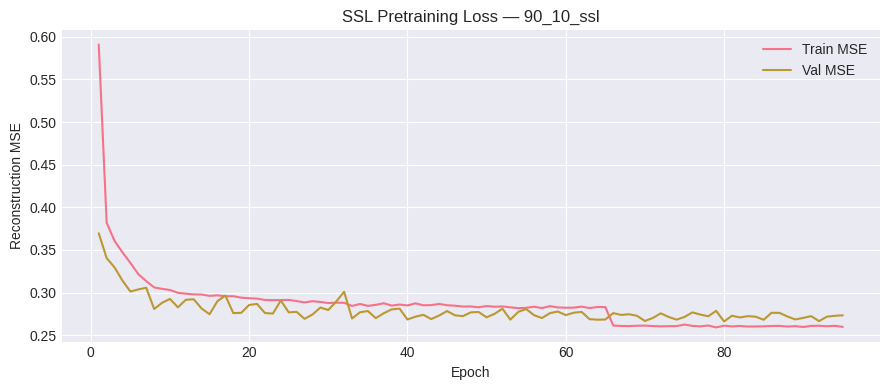

    SSL curves -> ssl_curves_90_10_ssl.png
  SSL model ready: /kaggle/working/ckpts_exB/tinymyo_90_10_ssl_ssl_pretrain.pt


In [14]:
print("\nSTEP 3 — SSL Pre-training (resume from Part-1 checkpoint)")

ssl_model  = TinyMyo(**ssl_kwargs)
pretrainer = SSLPretrainer(ssl_model, ssl_path_out)

# Build the SSL DataLoaders (train + val as unlabelled reconstruction targets)
mk_ssl = lambda idx, shuf: DataLoader(
    NormSubset(memmap_ds.X, y_np, idx),
    batch_size=Config.SSL_BATCH_SIZE, shuffle=shuf,
    num_workers=Config.NUM_WORKERS, pin_memory=False)

ssl_tr_loader  = mk_ssl(train_idx, True)
ssl_val_loader = mk_ssl(val_idx,   False)

if p1_ssl_latest.exists():
    # Resume from where Part 1 left off (epoch 65)
    print(f"  Found Part-1 latest SSL checkpoint at epoch {_epoch}. Resuming ...")
    try:
        pretrainer.resume_from(p1_ssl_latest, ssl_tr_loader, ssl_val_loader)
    except (KeyboardInterrupt, RuntimeError) as exc:
        print(f"  SSL pretraining interrupted: {exc}")
        if not ssl_path_out.exists():
            print("  ERROR: No best-model checkpoint available — cannot continue.")
            raise
        print("  Best-model checkpoint exists — continuing with saved model.")
else:
    # Part 1's best model already exists; no more pretraining epochs needed
    print("  No .latest.pt found — SSL pretraining appears complete. Using best model.")
    # Pretend pretrainer ran so history is populated from the best-model state
    # (history won't be available without the latest checkpoint, so we skip plotting)

assert ssl_path_out.exists(), f"SSL best model not found: {ssl_path_out}"

if pretrainer.history['train_loss']:
    plot_ssl_curves(pretrainer.history, TAG)
else:
    print("  Skipping SSL curve plot (history not available without .latest.pt).")

print(f"  SSL model ready: {ssl_path_out}")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## STEP 4 — Extract Frozen Features from SSL Backbone

In [15]:
print("\nSTEP 4 — Extracting frozen features from SSL backbone")

backbone   = load_ssl_backbone(ssl_kwargs, ssl_path_out, Config.DEVICE)
gflops_ssl = compute_gflops(backbone, N_CHANNELS)
print(f"  SSL encoder params: {backbone.count_params():,}  "
      f"GFLOPs/window: {gflops_ssl:.4f}")

print("  Extracting train features ...")
feat_tr, lbl_tr   = extract_features(backbone, mk_ssl(train_idx, False), Config.DEVICE)

print("  Extracting val features ...")
feat_val, lbl_val = extract_features(backbone, mk_ssl(val_idx, False), Config.DEVICE)

print("  Extracting test features ...")
feat_te, lbl_te   = extract_features(backbone, mk_ssl(test_idx, False), Config.DEVICE)

# Probe training uses ONLY train features — val is excluded to avoid data leakage
feat_probe_tr = feat_tr
lbl_probe_tr  = lbl_tr
print(f"  Feature dim: {feat_te.shape[1]}  "
      f"Probe train: {feat_probe_tr.shape[0]:,}  "
      f"(val excluded from probe training)  "
      f"Test: {feat_te.shape[0]:,}")

del backbone
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


STEP 4 — Extracting frozen features from SSL backbone
  [load_ssl_backbone] Encoder weights loaded OK (head skipped: 0 missing / 0 unexpected)
  SSL encoder params: 798,740  GFLOPs/window: -1.0000
  Extracting train features ...


  Extracting features:   0%|          | 0/278 [00:00<?, ?it/s]

  Extracting val features ...


  Extracting features:   0%|          | 0/31 [00:00<?, ?it/s]

  Extracting test features ...


  Extracting features:   0%|          | 0/35 [00:00<?, ?it/s]

  Feature dim: 128  Probe train: 70,966  (val excluded from probe training)  Test: 8,762


## STEP 5 — Downstream Probes


STEP 5 — Downstream probe evaluation (live computation)
    Training Linear Probe ... 

acc=0.2900  f1=0.2831  (75.1s train)
    Training MLP ... 

acc=0.7042  f1=0.7036  (163.2s train)
    Training SVM ... 

acc=0.5509  f1=0.5528  (2195.5s train)
    Training Decision Tree ... 

acc=0.4090  f1=0.4117  (24.0s train)
    Training Random Forest ... 

acc=0.6342  f1=0.6342  (121.2s train)


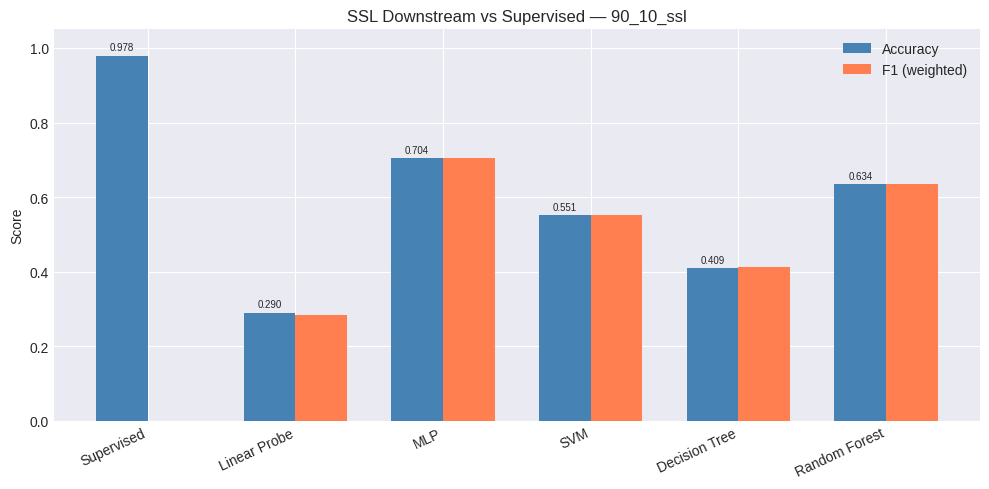

    Comparison chart -> downstream_comparison_90_10_ssl.png


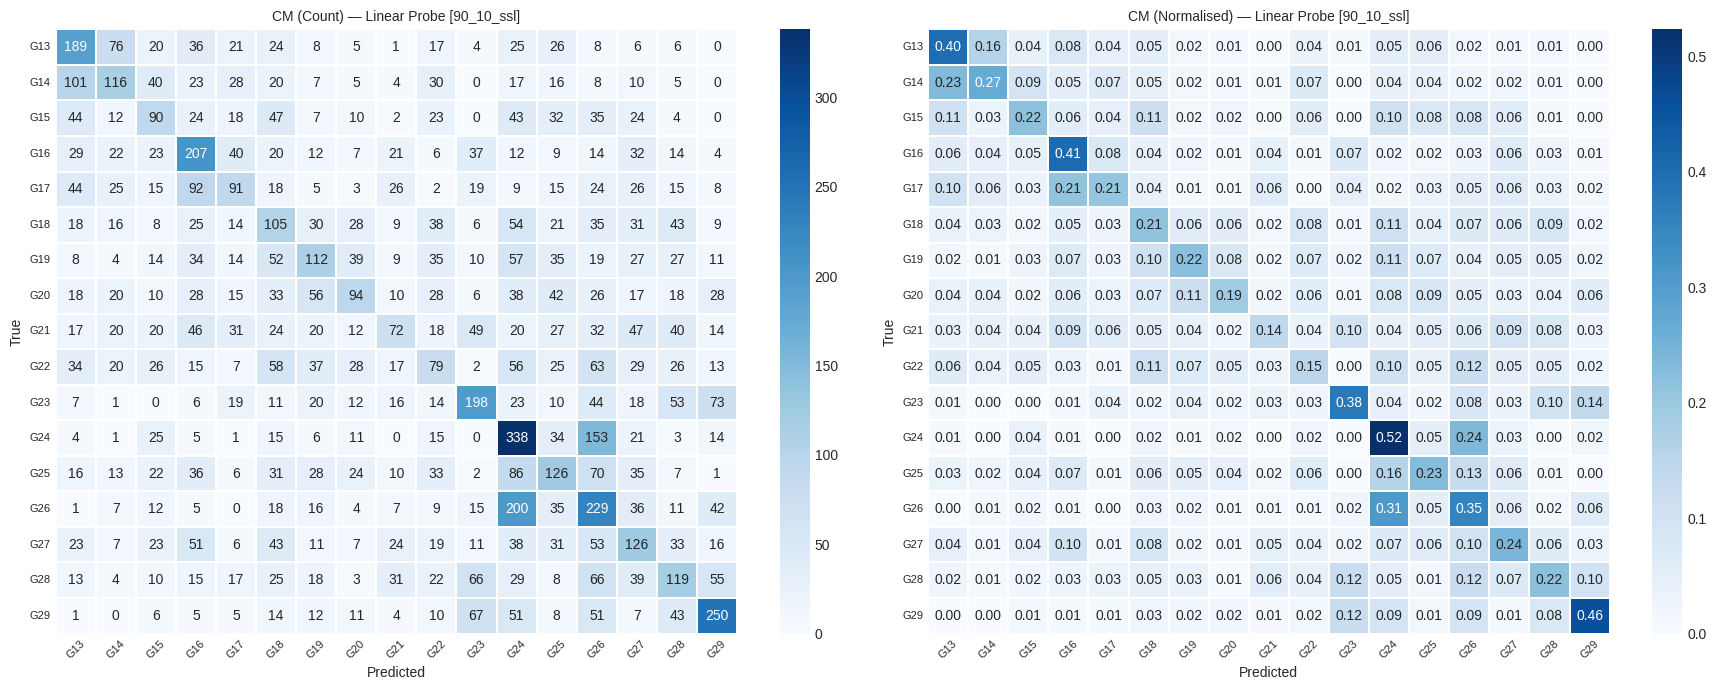

    CM saved -> cm_linear_probe_90_10_ssl.png


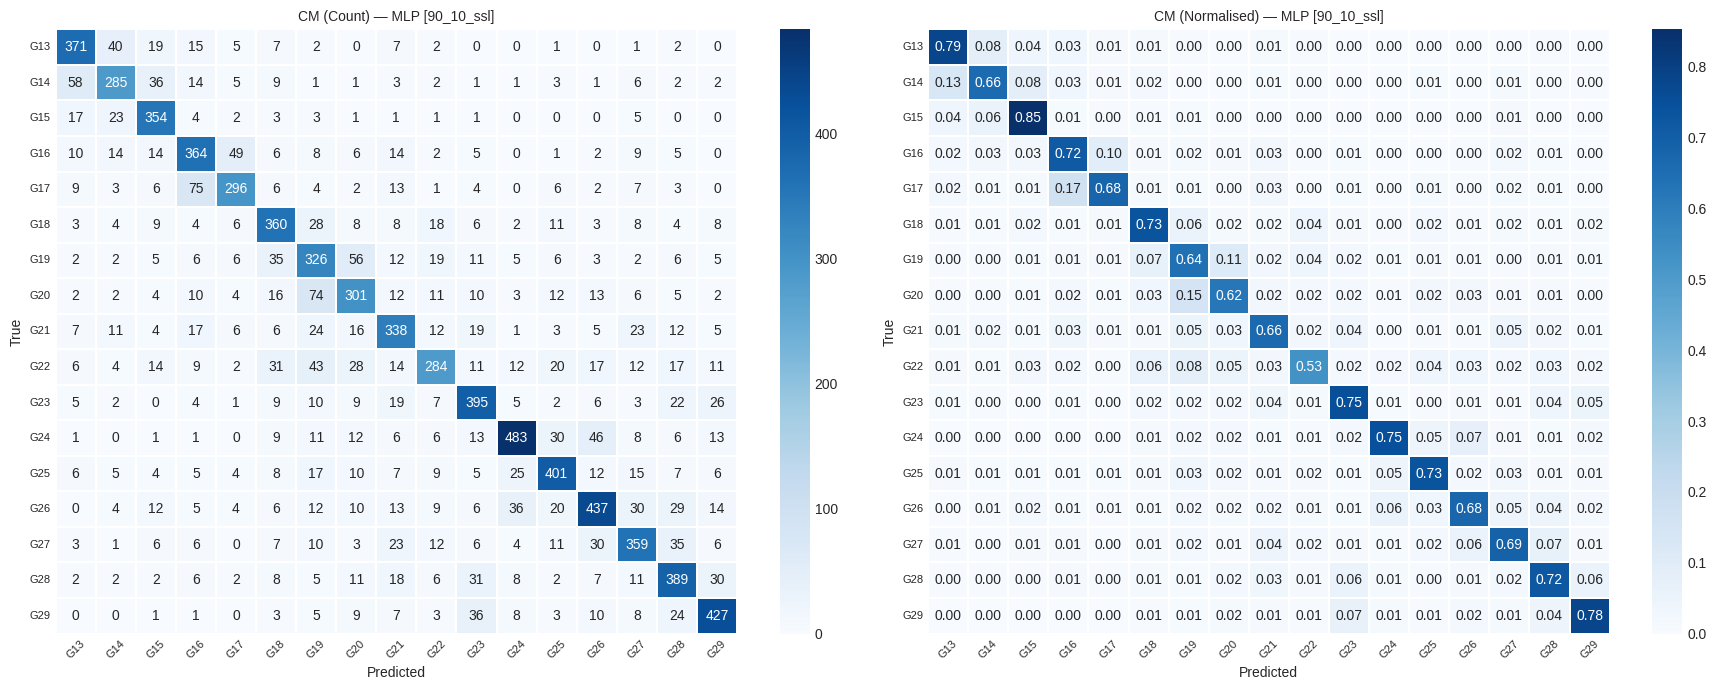

    CM saved -> cm_mlp_90_10_ssl.png


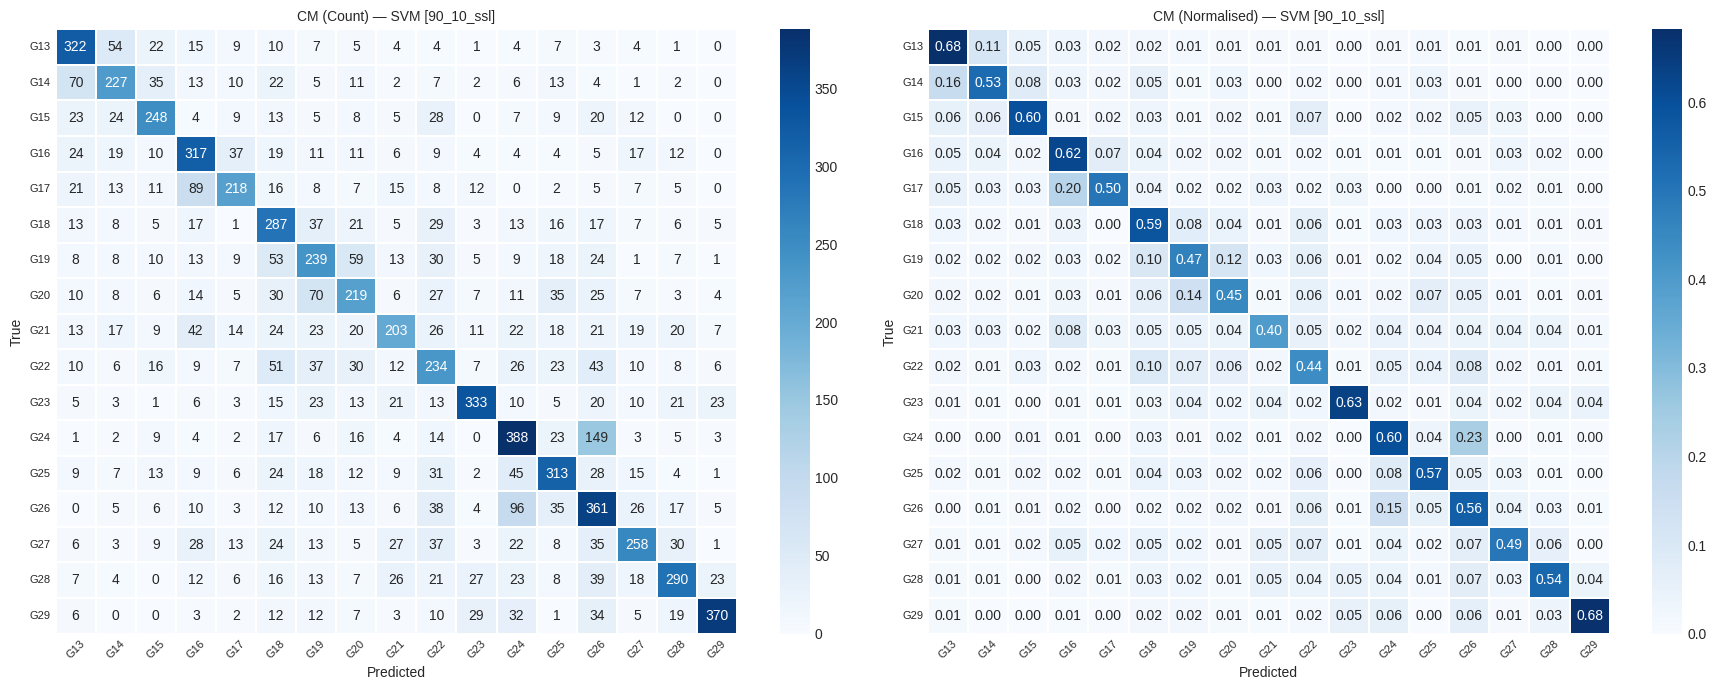

    CM saved -> cm_svm_90_10_ssl.png


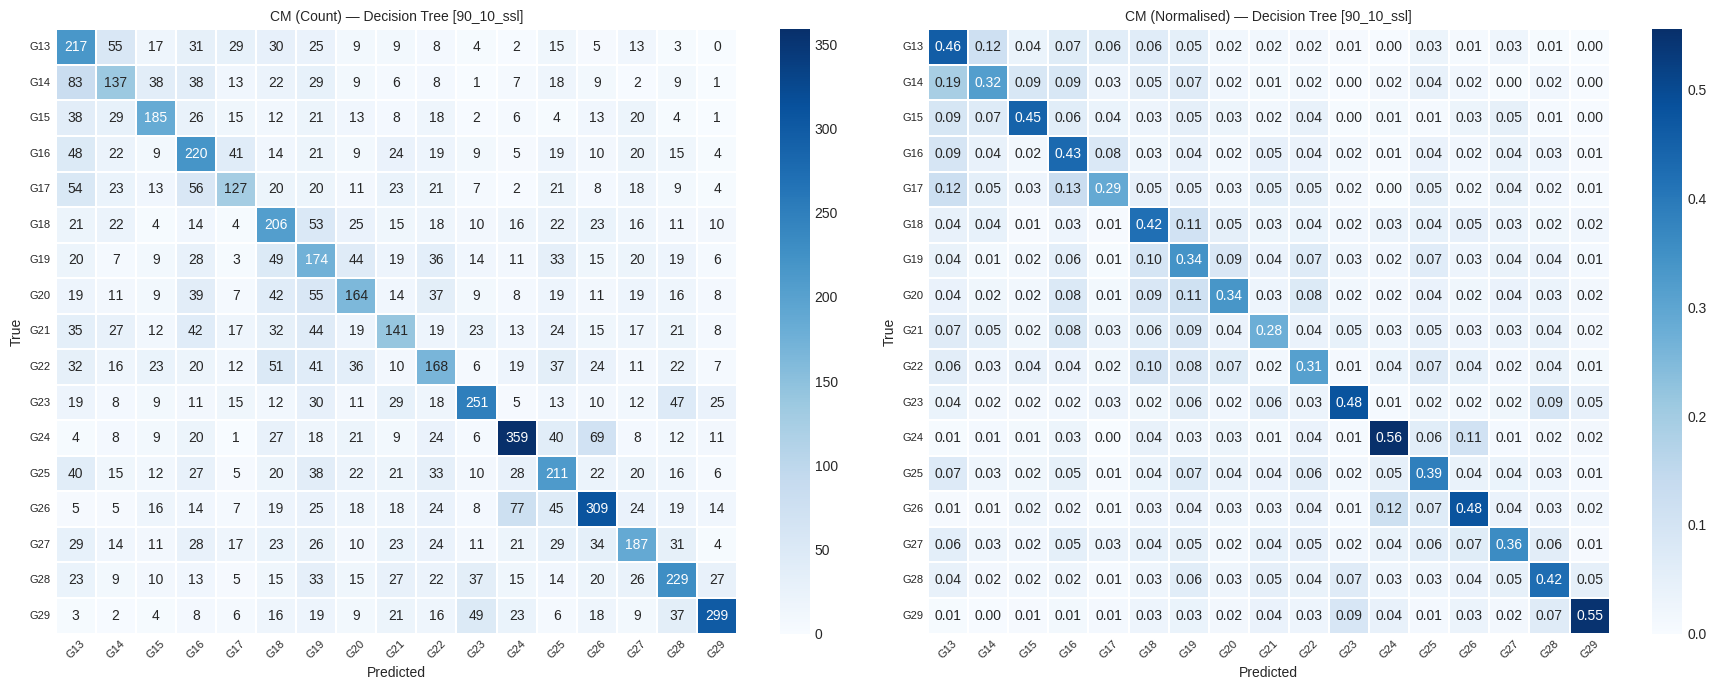

    CM saved -> cm_decision_tree_90_10_ssl.png


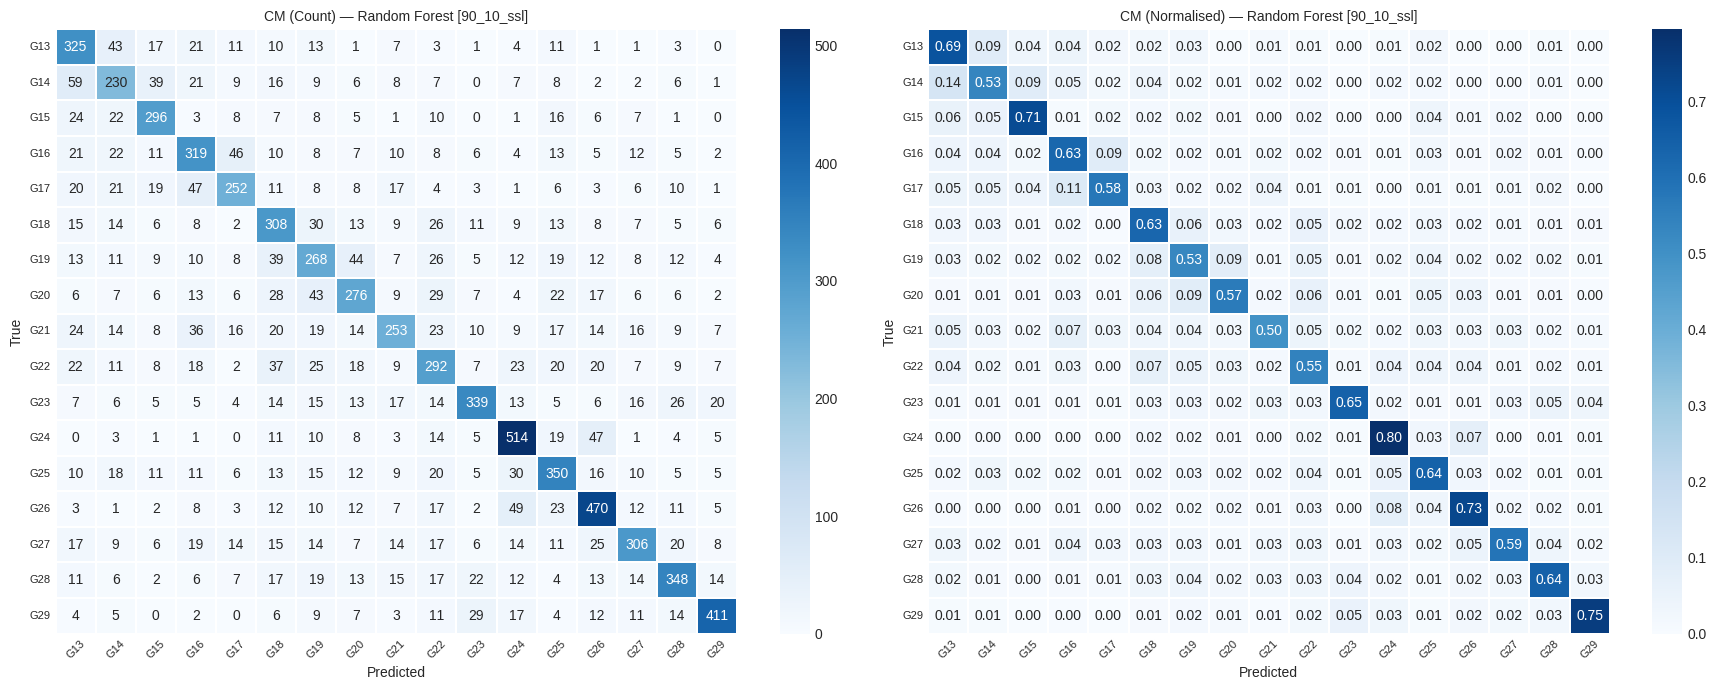

    CM saved -> cm_random_forest_90_10_ssl.png


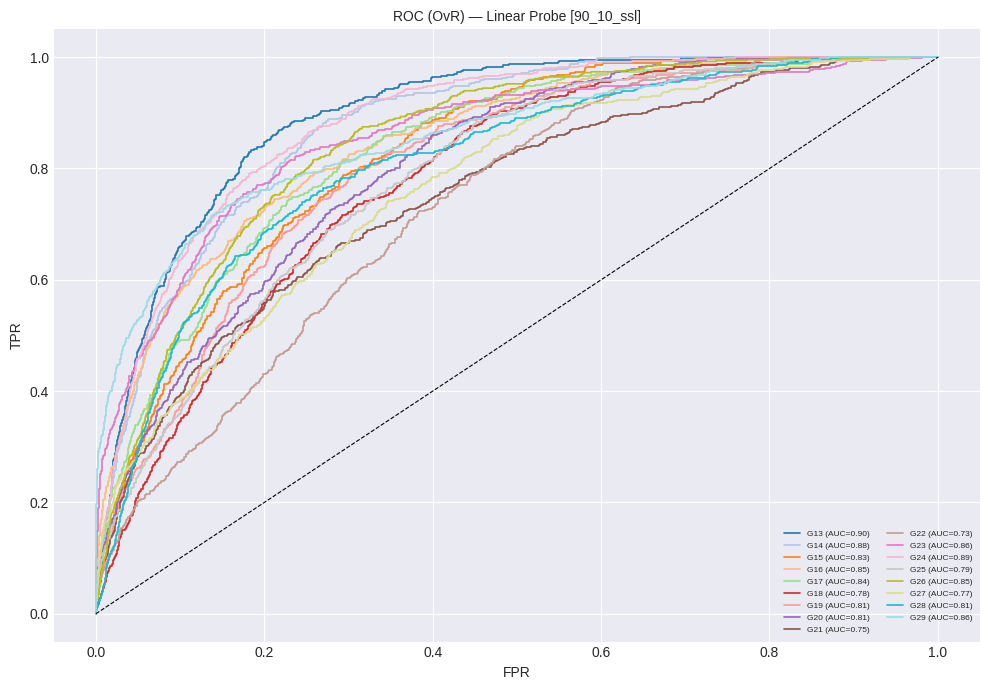

    ROC saved -> roc_linear_probe_90_10_ssl.png


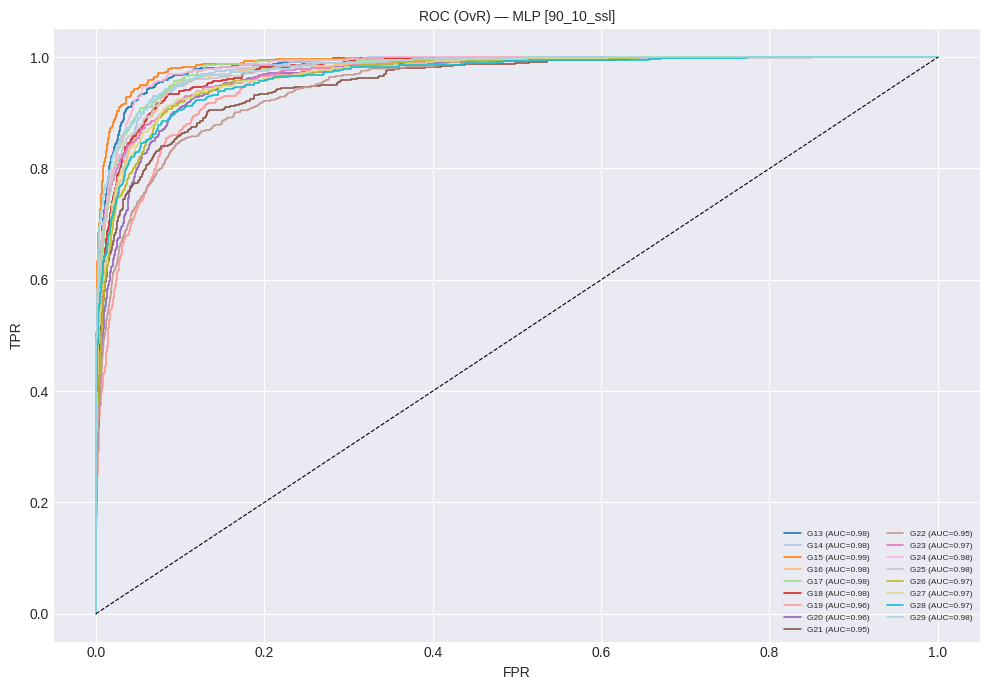

    ROC saved -> roc_mlp_90_10_ssl.png


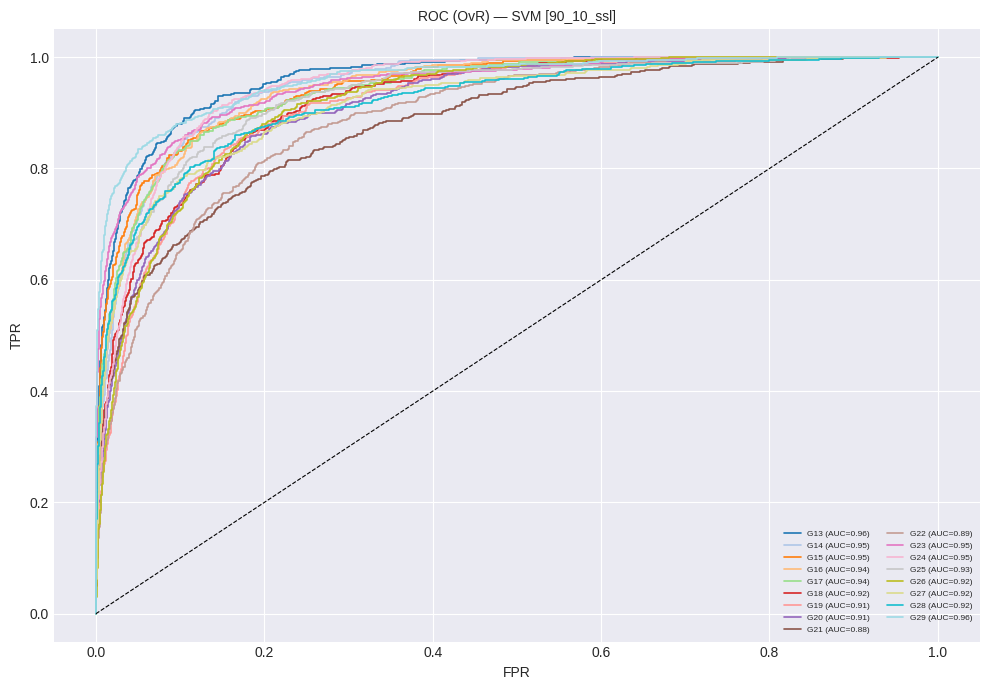

    ROC saved -> roc_svm_90_10_ssl.png


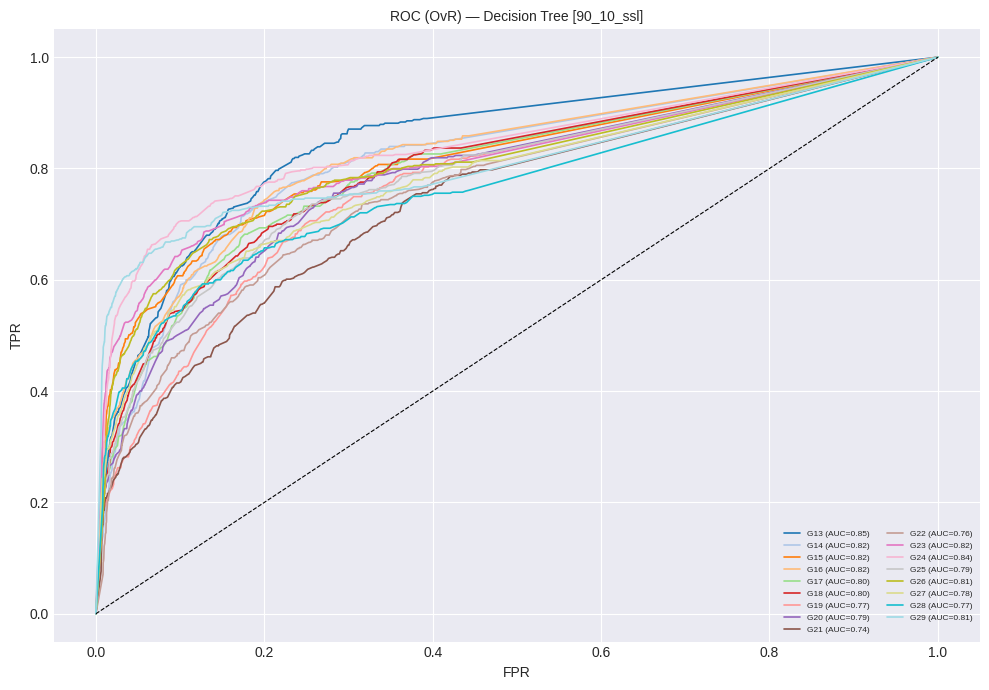

    ROC saved -> roc_decision_tree_90_10_ssl.png


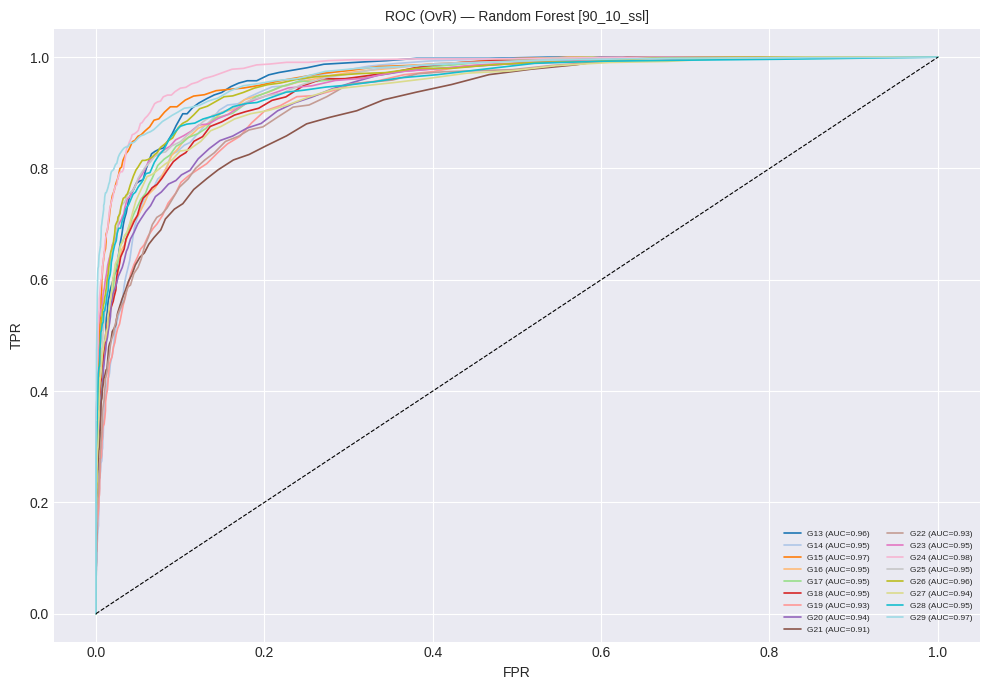

    ROC saved -> roc_random_forest_90_10_ssl.png

  Probe summary:
    Linear Probe          acc=0.2900  f1=0.2831  roc_auc=0.8227
    MLP                   acc=0.7042  f1=0.7036  roc_auc=0.9722
    SVM                   acc=0.5509  f1=0.5528  roc_auc=0.9293
    Decision Tree         acc=0.4090  f1=0.4117  roc_auc=0.8005
    Random Forest         acc=0.6342  f1=0.6342  roc_auc=0.9491


In [16]:
print("\nSTEP 5 — Downstream probe evaluation (live computation)")

probe_results, probe_scaler, fitted_probes = run_downstream_probes(
    feat_probe_tr, lbl_probe_tr,
    feat_te,       lbl_te,
    N_CLASSES, CLASS_NAMES)

supervised_acc = SUPERVISED_METRICS.get('accuracy', 0.9781)
plot_downstream_comparison(probe_results, supervised_acc, TAG)

# Scale test features with the probe scaler for confusion and ROC plots
Xte_scaled = probe_scaler.transform(feat_te)
plot_probe_confusions(Xte_scaled, lbl_te, fitted_probes, CLASS_NAMES, TAG)
plot_probe_roc(Xte_scaled, lbl_te, fitted_probes, CLASS_NAMES, TAG)

print("\n  Probe summary:")
for name, res in probe_results.items():
    print(f"    {name:20s}  acc={res['accuracy']:.4f}  f1={res['f1_w']:.4f}  "
          f"roc_auc={res['roc_auc_w']:.4f}")

## STEP 6 — Fine-Tuning from SSL Backbone

In [17]:
print("\nSTEP 6 — Fine-tuning from SSL backbone (wall-clock guarded)")

# If Part 1 happened to start fine-tuning, resume from that checkpoint;
# otherwise start fresh from the SSL backbone.
latest_ft_src = p1_ft_latest if p1_ft_latest.exists() else None

ft_trainer = finetune_from_ssl_resume(
    cls_kwargs,
    ssl_path      = ssl_path_out,
    latest_ft_path = latest_ft_src,
    train_loader  = tr_loader,
    val_loader    = val_loader,
    save_path     = ft_path_out,
    n_classes     = N_CLASSES,
    max_wall_s    = Config.FINETUNE_MAX_WALL,
)

plot_learning_curves(ft_trainer.history, TAG + '_ft')
print(f"  Fine-tune total epochs: {len(ft_trainer.history['train_loss'])}")


STEP 6 — Fine-tuning from SSL backbone (wall-clock guarded)
  No fine-tune checkpoint found; loading SSL backbone weights ...


  SSL -> classifier: loaded 53/55 param tensors (backbone only, head re-initialised)


    [ckpt] latest saved at epoch 5 -> tinymyo_90_10_ssl_finetune.latest.pt


    [ckpt] latest saved at epoch 10 -> tinymyo_90_10_ssl_finetune.latest.pt
  Epoch  10  train_loss=0.3087 train_acc=0.8941  val_loss=0.2964 val_acc=0.9015  (99.0 min)


    [ckpt] latest saved at epoch 15 -> tinymyo_90_10_ssl_finetune.latest.pt


    [ckpt] latest saved at epoch 20 -> tinymyo_90_10_ssl_finetune.latest.pt
  Epoch  20  train_loss=0.2027 train_acc=0.9295  val_loss=0.1979 val_acc=0.9365  (197.9 min)


    [ckpt] latest saved at epoch 25 -> tinymyo_90_10_ssl_finetune.latest.pt


    [ckpt] latest saved at epoch 30 -> tinymyo_90_10_ssl_finetune.latest.pt
  Epoch  30  train_loss=0.1493 train_acc=0.9482  val_loss=0.1782 val_acc=0.9412  (296.9 min)


    [ckpt] latest saved at epoch 35 -> tinymyo_90_10_ssl_finetune.latest.pt


## STEP 7 — Evaluate Fine-Tuned Model

In [ ]:
print("\nSTEP 7 — Evaluating fine-tuned model")

if ft_path_out.exists():
    ft_metrics, ft_true, ft_proba = evaluate_finetuned(
        cls_kwargs, ft_path_out, tst_loader, N_CLASSES, CLASS_NAMES, TAG + '_ft')
    ft_metrics['train_wall_s']   = ft_trainer.train_wall
    ft_metrics['epochs_trained'] = len(ft_trainer.history['train_loss'])

    print(f"  Fine-tune  acc={ft_metrics['accuracy']:.4f}  "
          f"f1={ft_metrics['f1_w']:.4f}  "
          f"ROC-AUC={ft_metrics['roc_auc_w']:.4f}")

    lp_acc = probe_results.get('Linear Probe', {}).get('accuracy', 0)
    print(f"  Linear probe acc={lp_acc:.4f}  "
          f"delta vs fine-tune={ft_metrics['accuracy'] - lp_acc:+.4f}")
    print(f"  Supervised   acc=0.9781  "
          f"delta vs fine-tune={ft_metrics['accuracy'] - 0.9781:+.4f}")
else:
    print("  No fine-tune best checkpoint found (hit wall limit before first improvement).")
    ft_metrics = {}

## STEP 8 — Embedding Analysis (PCA, t-SNE, UMAP)

In [ ]:
print("\nSTEP 8 — Embedding analysis on frozen test features")

sil, emb_tsne = plot_embeddings(feat_te, lbl_te, CLASS_NAMES, TAG)
print(f"  Silhouette score: {sil:.4f}")

## STEP 9 — k-NN Accuracy + Label-Efficiency Curve

In [ ]:
print("\nSTEP 9 — k-NN accuracy and label-efficiency curve")

print(f"  GFLOPs/window (SSL encoder): {gflops_ssl:.4f}")
print(f"  Silhouette score            : {sil:.4f}")

print("\n  k-NN accuracy in embedding space:")
knn_res = knn_accuracy(feat_probe_tr, lbl_probe_tr, feat_te, lbl_te)

print("\n  Label-efficiency curve (linear probe on frozen features):")
le_res = label_efficiency_curve(feat_probe_tr, lbl_probe_tr, feat_te, lbl_te)

## STEP 10 — Final Summary Table

In [ ]:
print("\nFINAL SUMMARY — All Methods")

rows = [{'method': 'Supervised (Part-3)',
          **{k: SUPERVISED_METRICS.get(k, float('nan'))
             for k in ['accuracy', 'precision_w', 'recall_w', 'f1_w', 'roc_auc_w']}}]

for name, res in probe_results.items():
    rows.append({'method': f'SSL frozen -> {name}',
                  **{k: res.get(k, float('nan'))
                     for k in ['accuracy', 'precision_w', 'recall_w',
                                'f1_w', 'roc_auc_w']}})

if ft_metrics:
    rows.append({'method': 'SSL Fine-tune',
                  **{k: ft_metrics.get(k, float('nan'))
                     for k in ['accuracy', 'precision_w', 'recall_w',
                                'f1_w', 'roc_auc_w']}})

for k_val, acc in knn_res.items():
    rows.append({'method': f'SSL kNN (k={k_val})',
                  'accuracy': acc,
                  'precision_w': float('nan'), 'recall_w': float('nan'),
                  'f1_w': float('nan'), 'roc_auc_w': float('nan')})

df_summary = pd.DataFrame(rows)
csv_path   = Config.RESULTS_DIR / 'summary_all_methods_p2.csv'
df_summary.to_csv(csv_path, index=False)
print(df_summary[['method', 'accuracy', 'f1_w', 'roc_auc_w']].to_string(index=False))

fig, ax = plt.subplots(figsize=(max(10, len(rows) * 1.4), 5))
methods = [r['method'] for r in rows]
accs    = [r['accuracy'] for r in rows]
f1s     = [r['f1_w'] for r in rows]
x = np.arange(len(methods))
w = 0.35
ax.bar(x - w/2, accs, w, label='Accuracy', color='steelblue')
ax.bar(x + w/2, f1s,  w, label='F1 (weighted)', color='coral')
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Final Method Comparison — Part 2')
ax.legend()
plt.tight_layout()
summary_plot = Config.PLOT_DIR / 'final_summary_p2.png'
plt.savefig(summary_plot, dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

# Save full results to JSON
ssl_results_p2 = {
    'downstream':       probe_results,
    'finetune':         ft_metrics,
    'silhouette':       float(sil),
    'knn':              knn_res,
    'label_efficiency': le_res,
    'ssl_pretraining': {
        'epochs':          len(pretrainer.history['train_loss']),
        'final_val_mse':   (pretrainer.history['val_loss'][-1]
                            if pretrainer.history['val_loss'] else None),
        'wall_s':          pretrainer.train_wall,
    },
    'gflops_ssl': gflops_ssl,
}

def serialise(obj):
    if isinstance(obj, (np.integer, np.floating)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return str(obj)

jpath = Config.RESULTS_DIR / f'ssl_results_{TAG}_p2.json'
with open(jpath, 'w') as f:
    json.dump(json.loads(json.dumps(ssl_results_p2, default=serialise)), f, indent=2)

print(f"\n  CSV    -> {csv_path}")
print(f"  JSON   -> {jpath}")
print(f"  Plots  -> {Config.PLOT_DIR}")
print(f"  Models -> {Config.CKPT_DIR}")

if le_res:
    print("\n  Label-efficiency (linear probe):")
    for frac, res in sorted(le_res.items()):
        print(f"    {frac:5.0%} -> acc={res['accuracy']:.4f}  (n={res['n_labeled']:,})")